# WISE $W2$ Period-Luminosity Relations for Clean Gaia RR Lyrae

This notebook extends the cleaned Gaia RR Lyrae calibration sample into the **near-infrared** by cross-matching the clean Gaia sample to **AllWISE** through the Gaia Archive best-neighbour tables. The scientific goal is the same as in `02-02.ipynb`: fit subclass-separated Bayesian period-luminosity relations with intrinsic scatter. The key difference is that the dependent variable is now the catalog **WISE $W2$ magnitude** rather than Gaia $G$.

For RR Lyrae stars, moving from a broad optical band such as Gaia $G$ into the near-infrared is astrophysically well motivated. The broad optical relation is widened by temperature sensitivity, residual extinction, and population effects, whereas infrared RR Lyrae relations are expected to be **tighter** and often **steeper** because they are less sensitive to dust and to the temperature-driven light-curve morphology that dominates at shorter wavelengths ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776); [Beaton et al. 2018](https://arxiv.org/abs/1805.01552)).

This notebook keeps the same subclass logic as `02-02.ipynb`:

- fit **RRab** and **RRc** separately,
- exclude **RRd** from the fit,
- propagate the catalog period uncertainties into the model variance,
- use the native PyMC formulation of the model,
- compare the resulting $W2$ relations directly against the previously fitted Gaia $G$ relations saved in `rrlyrae_optical_pl_comparison_data.npz`.


## Query Strategy and Handoff Artifacts

The Gaia+WISE query is intentionally broad. It pulls the Gaia RR Lyrae variability table, the matching Gaia source columns needed for distance and quality diagnostics, and the WISE best-neighbour / neighbourhood metadata plus the catalog $W2$ photometry. The notebook **does not** reconstruct the Gaia cleaning pipeline from scratch. Instead, it loads `rrlyrae_calibration_sample.npz` and uses the saved `source_id` list as the canonical definition of the clean Gaia sample. The Gaia+WISE query result is then filtered back down to exactly those same clean Gaia objects.

This split is deliberate:

- `02-01.ipynb` remains the notebook that defines the clean Gaia calibration sample,
- `03.ipynb` is the notebook that studies what happens when those same stars are cross-matched to WISE.


In [1]:
from pathlib import Path
from types import SimpleNamespace

from astropy import table
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    WISEQualityFilter,
    attach_w2_absolute_magnitude,
    build_band_summary,
    build_infrared_pl_comparison_data,
    build_w2_context,
    fit_w2_nuts,
    load_optical_pl_comparison_data,
    load_or_create_table_npz,
    load_table_npz,
    mcmc_sampler_color,
    plot_corner,
    plot_mollweide_diff,
    plot_optical_vs_w2_comparison,
    plot_period_abs_mag,
    plot_period_abs_mag_comparison,
    plot_trace,
    plot_w2_posterior_predictive,
    save_infrared_pl_comparison_data,
    w2_posterior_summary_row,
)

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
DISPLAY_LABELS = [r"$a$", r"$b$", r"$\sigma_{\rm scatter}$"]
SLOPE_PRIOR_SIGMA = 5.0
INTERCEPT_PRIOR_SIGMA = 1.0
SIGMA_SCATTER_SCALE = 0.5
NUTS_DRAWS = 2_000
NUTS_TUNE = 1_000

clean_path = Path("rrlyrae_calibration_sample.npz")
optical_path = Path("rrlyrae_optical_pl_comparison_data.npz")
gaia_wise_cache_path = Path("rrlyrae_gaia_wise_query_data.npz")

infrared_path = Path("rrlyrae_infrared_pl_comparison_data.npz")


## Gaia Archive Query

The query uses a broad `SELECT *` across the joined tables. It keeps the **full Gaia RR Lyrae sample** and attaches WISE via `LEFT OUTER JOIN`, so stars without a WISE counterpart remain in the result with null WISE fields. That is what we want here, because the notebook needs to quantify the difference between:

1. the clean Gaia sample,
2. the subset with any WISE best-neighbour match,
3. the final conservative WISE-quality subset used for the Bayesian fit.

If your archive mirror exposes the AllWISE source table under a different schema, edit the table name directly in the query cell below.


In [3]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
LEFT OUTER JOIN gaiadr3.allwise_best_neighbour AS bn
    ON vr.source_id = bn.source_id
LEFT OUTER JOIN gaiadr3.allwise_neighbourhood AS nh
    ON bn.source_id = nh.source_id
   AND bn.allwise_oid = nh.allwise_oid
LEFT OUTER JOIN gaiadr1.allwise_original_valid AS aw
    ON bn.allwise_oid = aw.allwise_oid
"""


In [4]:
def _fetch_gaia_wise_table():
    return GaiaData(query).data


gaia_wise_data, cache_status = load_or_create_table_npz(
    gaia_wise_cache_path,
    _fetch_gaia_wise_table,
)

{
    "cache": str(gaia_wise_cache_path.resolve()),
    "status": cache_status,
    "rows": len(gaia_wise_data),
}


{'cache': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_gaia_wise_query_data.npz',
 'status': 'loaded',
 'rows': 271779}

In [5]:
len(gaia_wise_data)


271779

## Restrict the Query Result to the Canonical Clean Gaia Sample

`rrlyrae_calibration_sample.npz` is the handoff artifact from `02-01.ipynb`. Here it is used only to recover the canonical clean Gaia `source_id` list. The WISE analysis should therefore be understood as:

- start from the exact same clean Gaia RR Lyrae sample,
- ask which of those stars have a WISE best-neighbour match,
- then ask which of those matches are conservative enough to use for a subclass-separated $W2$ period-luminosity fit.


In [6]:
clean_sample = load_table_npz(clean_path)
clean_source_ids = np.asarray(clean_sample["source_id"], dtype=np.int64)

clean_mask = np.isin(np.asarray(gaia_wise_data["source_id"], dtype=np.int64), clean_source_ids)
clean_gaia_wise_data = gaia_wise_data[clean_mask]

print({
    "clean source_id count": len(clean_source_ids),
    "rows recovered from Gaia+WISE query": len(clean_gaia_wise_data),
    "missing source_ids": int(len(clean_source_ids) - len(clean_gaia_wise_data)),
})


{'clean source_id count': 884, 'rows recovered from Gaia+WISE query': 884, 'missing source_ids': 0}


In [7]:
optical_comparison = load_optical_pl_comparison_data(optical_path)
optical_comparison


{'RRab': OpticalPLComparisonData(rr_class='RRab', x_obs=array([-0.25184385, -0.20091848, -0.303203  , -0.21551645, -0.22027848,
        -0.19766999, -0.07887569, -0.30378994, -0.21978989, -0.17868373,
        -0.19625344, -0.31750689, -0.26126791, -0.33251033, -0.17206964,
        -0.20987007, -0.20319154, -0.23950737, -0.1259878 , -0.35617763,
        -0.22548943, -0.2144865 , -0.20597658, -0.21248299, -0.11370844,
        -0.13499291, -0.29125108, -0.12691965, -0.10438656, -0.2110517 ,
        -0.26127251, -0.19379178, -0.31728278, -0.25629611, -0.15731574,
        -0.25954065, -0.34515899, -0.21578161, -0.25769556, -0.32236602,
        -0.29059991, -0.09487302, -0.33378262, -0.32105583, -0.38509076,
        -0.09264672, -0.15575027, -0.30324098, -0.24914175, -0.11426837,
        -0.21533062, -0.29221935, -0.2569637 , -0.26900363, -0.2536235 ,
        -0.29061703, -0.32868877, -0.18481212, -0.26187008, -0.11481233,
        -0.31539557, -0.16389503, -0.34983509, -0.36195228, -0.321515

In [8]:
def _col_as_float(column):
    values = np.ma.asarray(column, dtype=float)
    return np.asarray(np.ma.filled(values, np.nan), dtype=float)


def _col_as_str(column):
    values = np.ma.asarray(column, dtype=object)
    filled = np.ma.filled(values, "")
    return np.asarray([str(v).strip() if v is not None else "" for v in filled], dtype=str)


def _char_at(column, idx):
    strings = _col_as_str(column)
    return np.asarray([value[idx] if len(value) > idx else "" for value in strings], dtype=str)


def _first_present_float(data, names):
    for name in names:
        if name in data.colnames:
            return _col_as_float(data[name])
    raise KeyError(f"Missing all candidate columns: {names}")

In [9]:
clean_gaia_wise_data = attach_w2_absolute_magnitude(clean_gaia_wise_data)

allwise_oid = _col_as_float(clean_gaia_wise_data["allwise_oid"])
matched_best_neighbour_data = clean_gaia_wise_data[np.isfinite(allwise_oid)]

rr_classes = _col_as_str(matched_best_neighbour_data["best_classification"])
matched_best_neighbour_rr_data = matched_best_neighbour_data[np.isin(rr_classes, ["RRab", "RRc", "RRd"])]

wise_clean_data = WISEQualityFilter(matched_best_neighbour_rr_data).data

stage_counts = table.Table(
    rows=[
        {"stage": "Clean Gaia sample", "N": len(clean_gaia_wise_data)},
        {"stage": "With any WISE best-neighbour match", "N": len(matched_best_neighbour_data)},
        {"stage": "Matched RRab/RRc/RRd subset", "N": len(matched_best_neighbour_rr_data)},
        {"stage": "Final conservative WISE-quality subset", "N": len(wise_clean_data)},
    ]
)

matched_class_counts = {
    label: int(np.count_nonzero(_col_as_str(matched_best_neighbour_rr_data["best_classification"]) == label))
    for label in ("RRab", "RRc", "RRd")
}
wise_class_counts = {
    label: int(np.count_nonzero(_col_as_str(wise_clean_data["best_classification"]) == label))
    for label in ("RRab", "RRc", "RRd")
}
class_counts = table.Table(
    rows=[
        {
            "class": label,
            "best_neighbour_matches": matched_class_counts[label],
            "final_wise_quality": wise_class_counts[label],
        }
        for label in ("RRab", "RRc", "RRd")
    ]
)

stage_counts, class_counts

(<Table length=4>
                 stage                    N  
                 str38                  int64
 -------------------------------------- -----
                      Clean Gaia sample   884
     With any WISE best-neighbour match   876
            Matched RRab/RRc/RRd subset   876
 Final conservative WISE-quality subset   840,
 <Table length=3>
 class best_neighbour_matches final_wise_quality
  str4         int64                int64       
 ----- ---------------------- ------------------
  RRab                    556                527
   RRc                    312                305
   RRd                      8                  8)

## WISE Match Quality and Final Fit Sample

The Gaia best-neighbour tables tell us which AllWISE source is the preferred match, but they do not automatically guarantee that the match is unique or that the WISE photometry is of the quality we want for a period-luminosity calibration. This notebook therefore separates the WISE workflow into two stages.

1. **Diagnostic matched sample**: every clean Gaia RR Lyrae star with any WISE best-neighbour entry.
2. **Final fit sample**: a conservative subset requiring a unique best-neighbour match and good WISE $W2$ photometric quality.

The final cut is intentionally conservative. It keeps only stars with:

- a unique Gaia↔WISE association (`number_of_mates == 0` and `number_of_neighbours == 1` in this archive export),
- finite $W2$ magnitude and uncertainty,
- good $W2$ photometric quality (`ph_qual` second character `A` or `B`),
- no W2 contamination/confusion flag (`cc_flags` second character `0`),
- low WISE extended-source flag (`ext_flag <= 1`; some mirrors expose this as `ext_flg`).

The notebook does **not** reject stars using `var_flg`, because RR Lyrae stars are genuinely variable and WISE variability flags are not a reason to discard them from a variable-star calibration sample.


In [10]:
stage_counts


stage,N
str38,int64
Clean Gaia sample,884
With any WISE best-neighbour match,876
Matched RRab/RRc/RRd subset,876
Final conservative WISE-quality subset,840


In [11]:
class_counts


class,best_neighbour_matches,final_wise_quality
str4,int64,int64
RRab,556,527
RRc,312,305
RRd,8,8


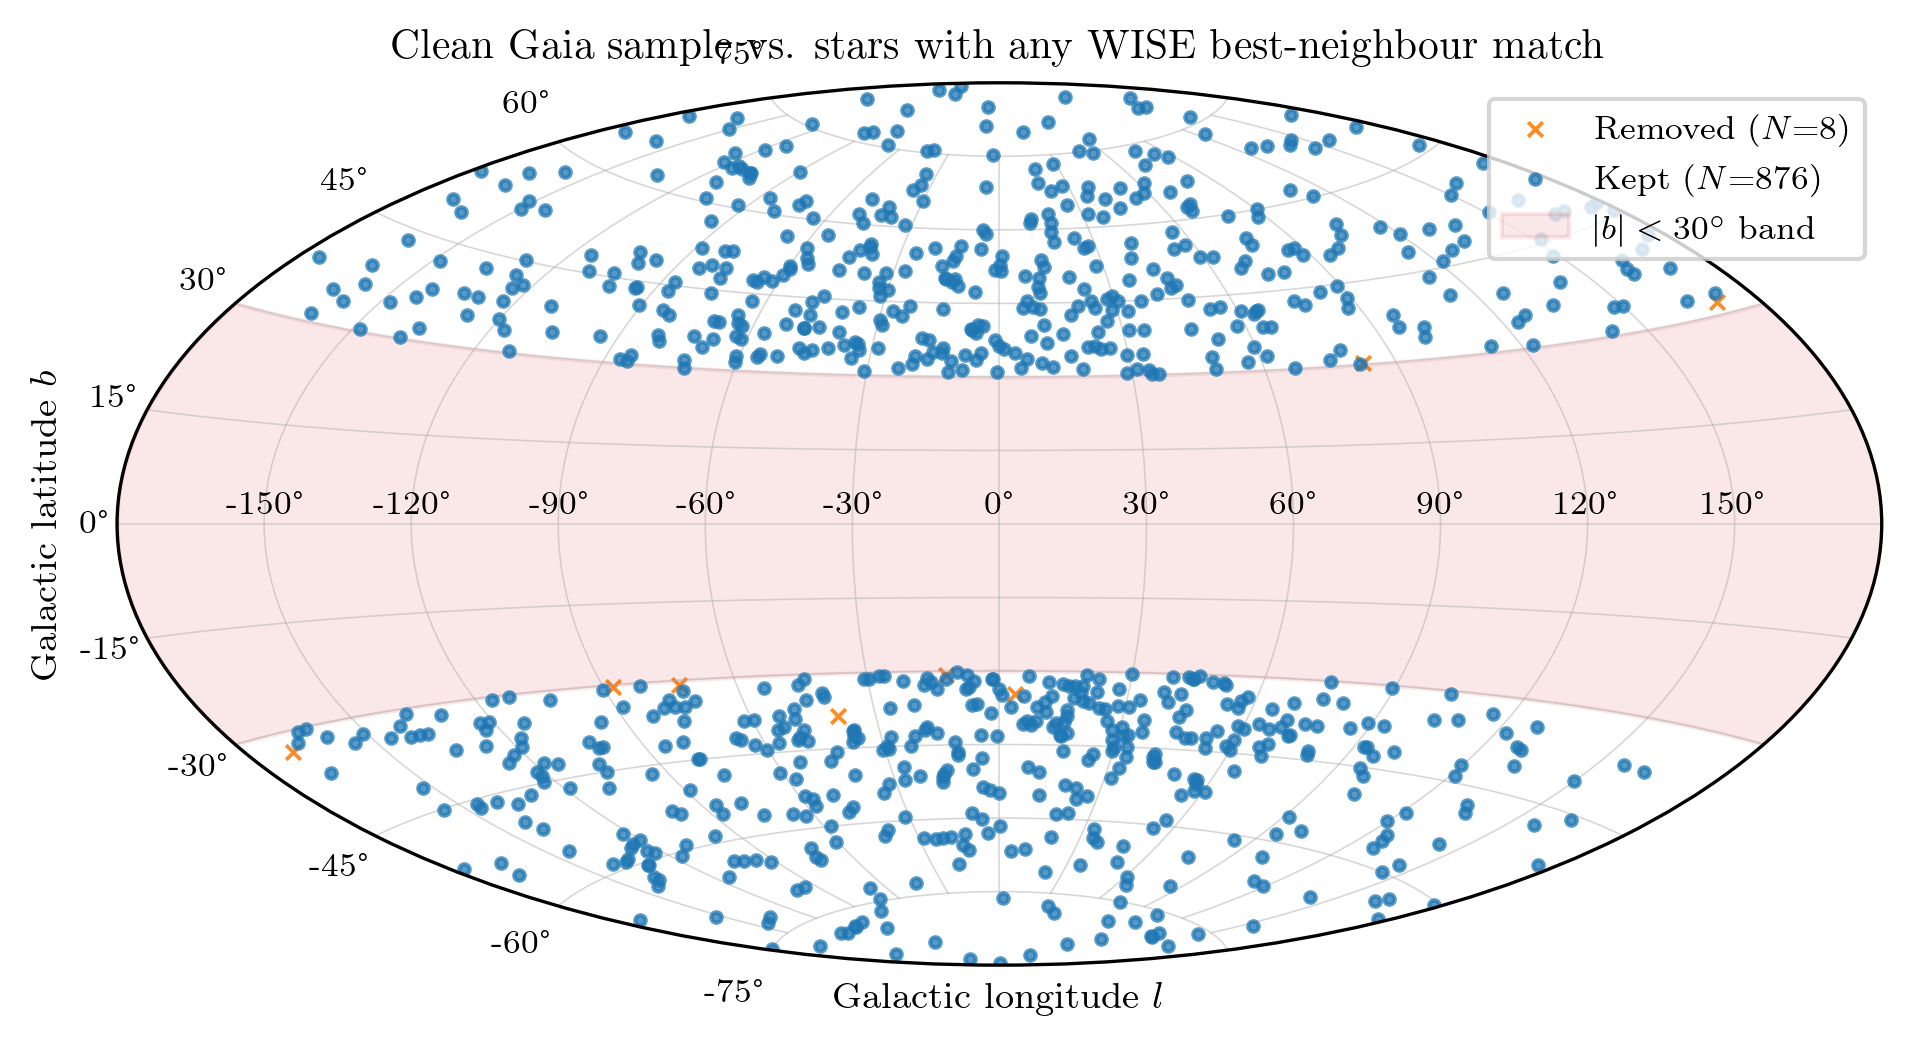

In [12]:
ax = plot_mollweide_diff(clean_gaia_wise_data, matched_best_neighbour_data)
ax.set_title("Clean Gaia sample vs. stars with any WISE best-neighbour match")
plt.show()


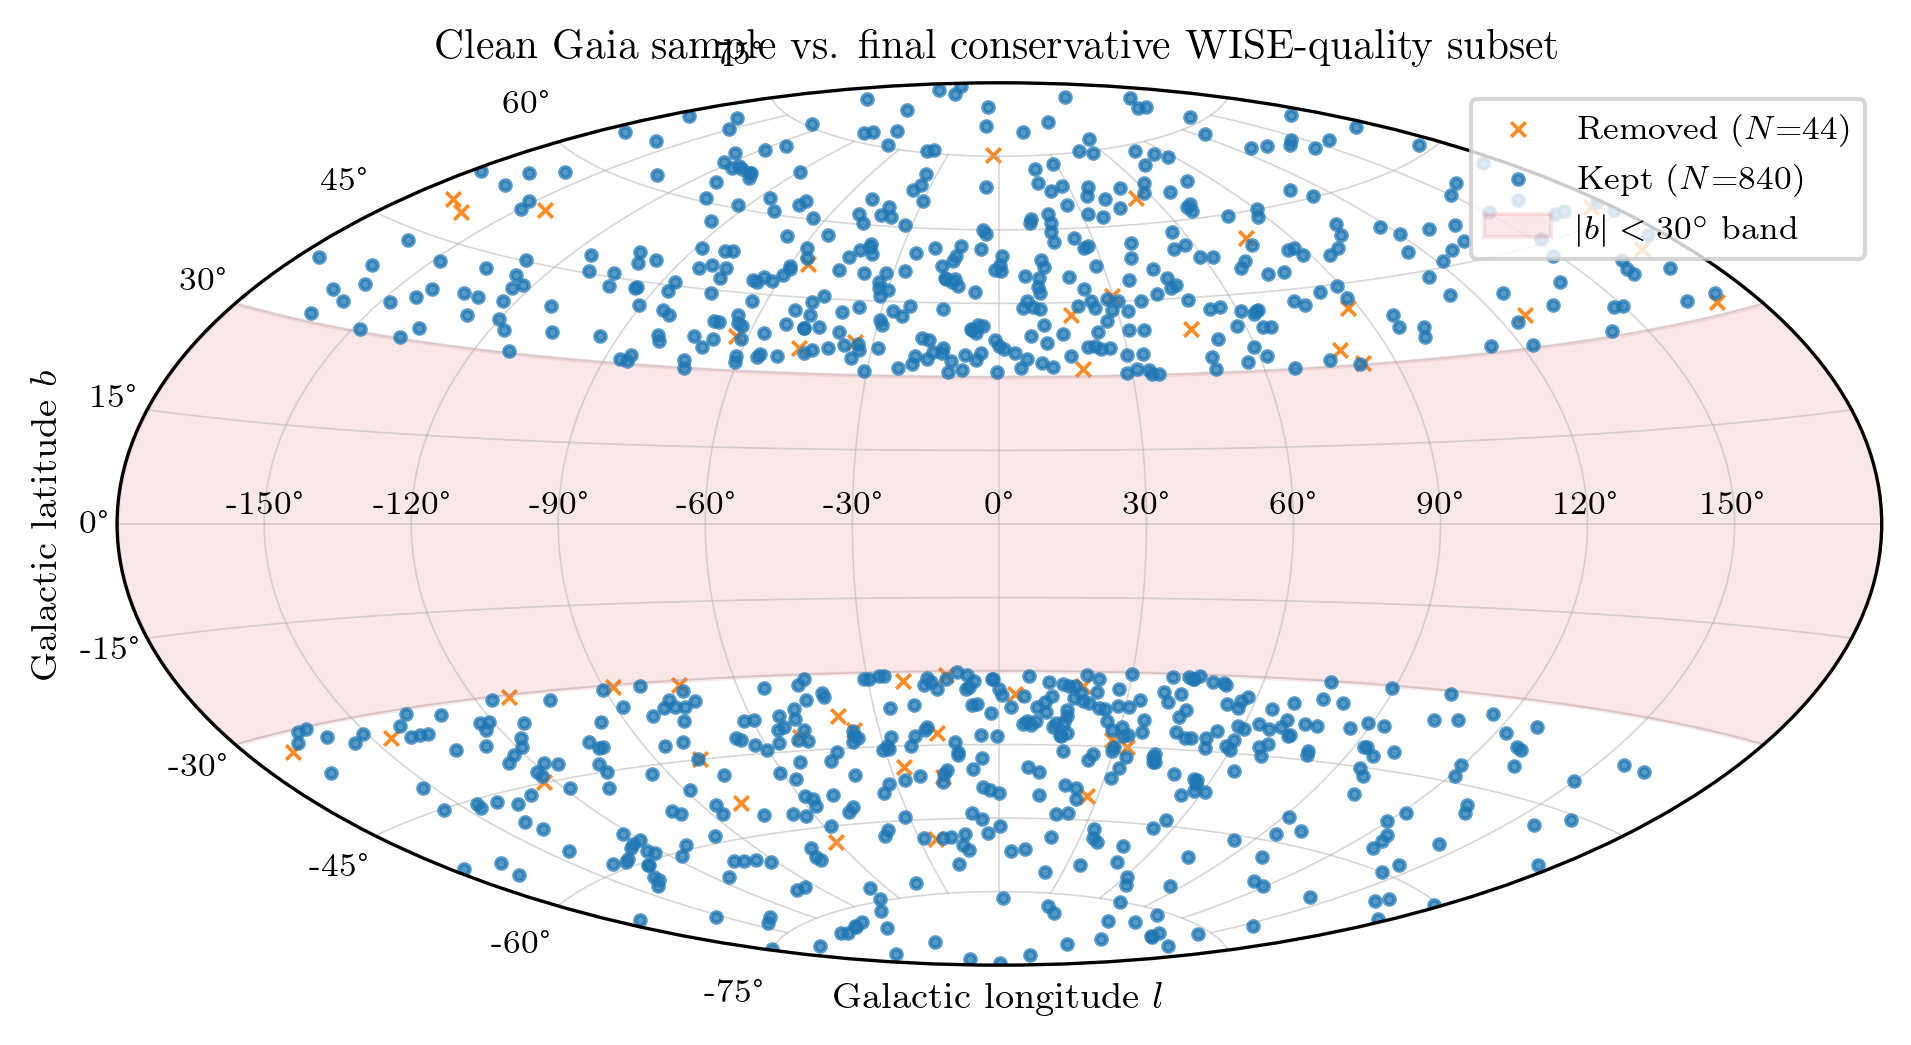

In [13]:
ax = plot_mollweide_diff(clean_gaia_wise_data, wise_clean_data)
ax.set_title("Clean Gaia sample vs. final conservative WISE-quality subset")
plt.show()


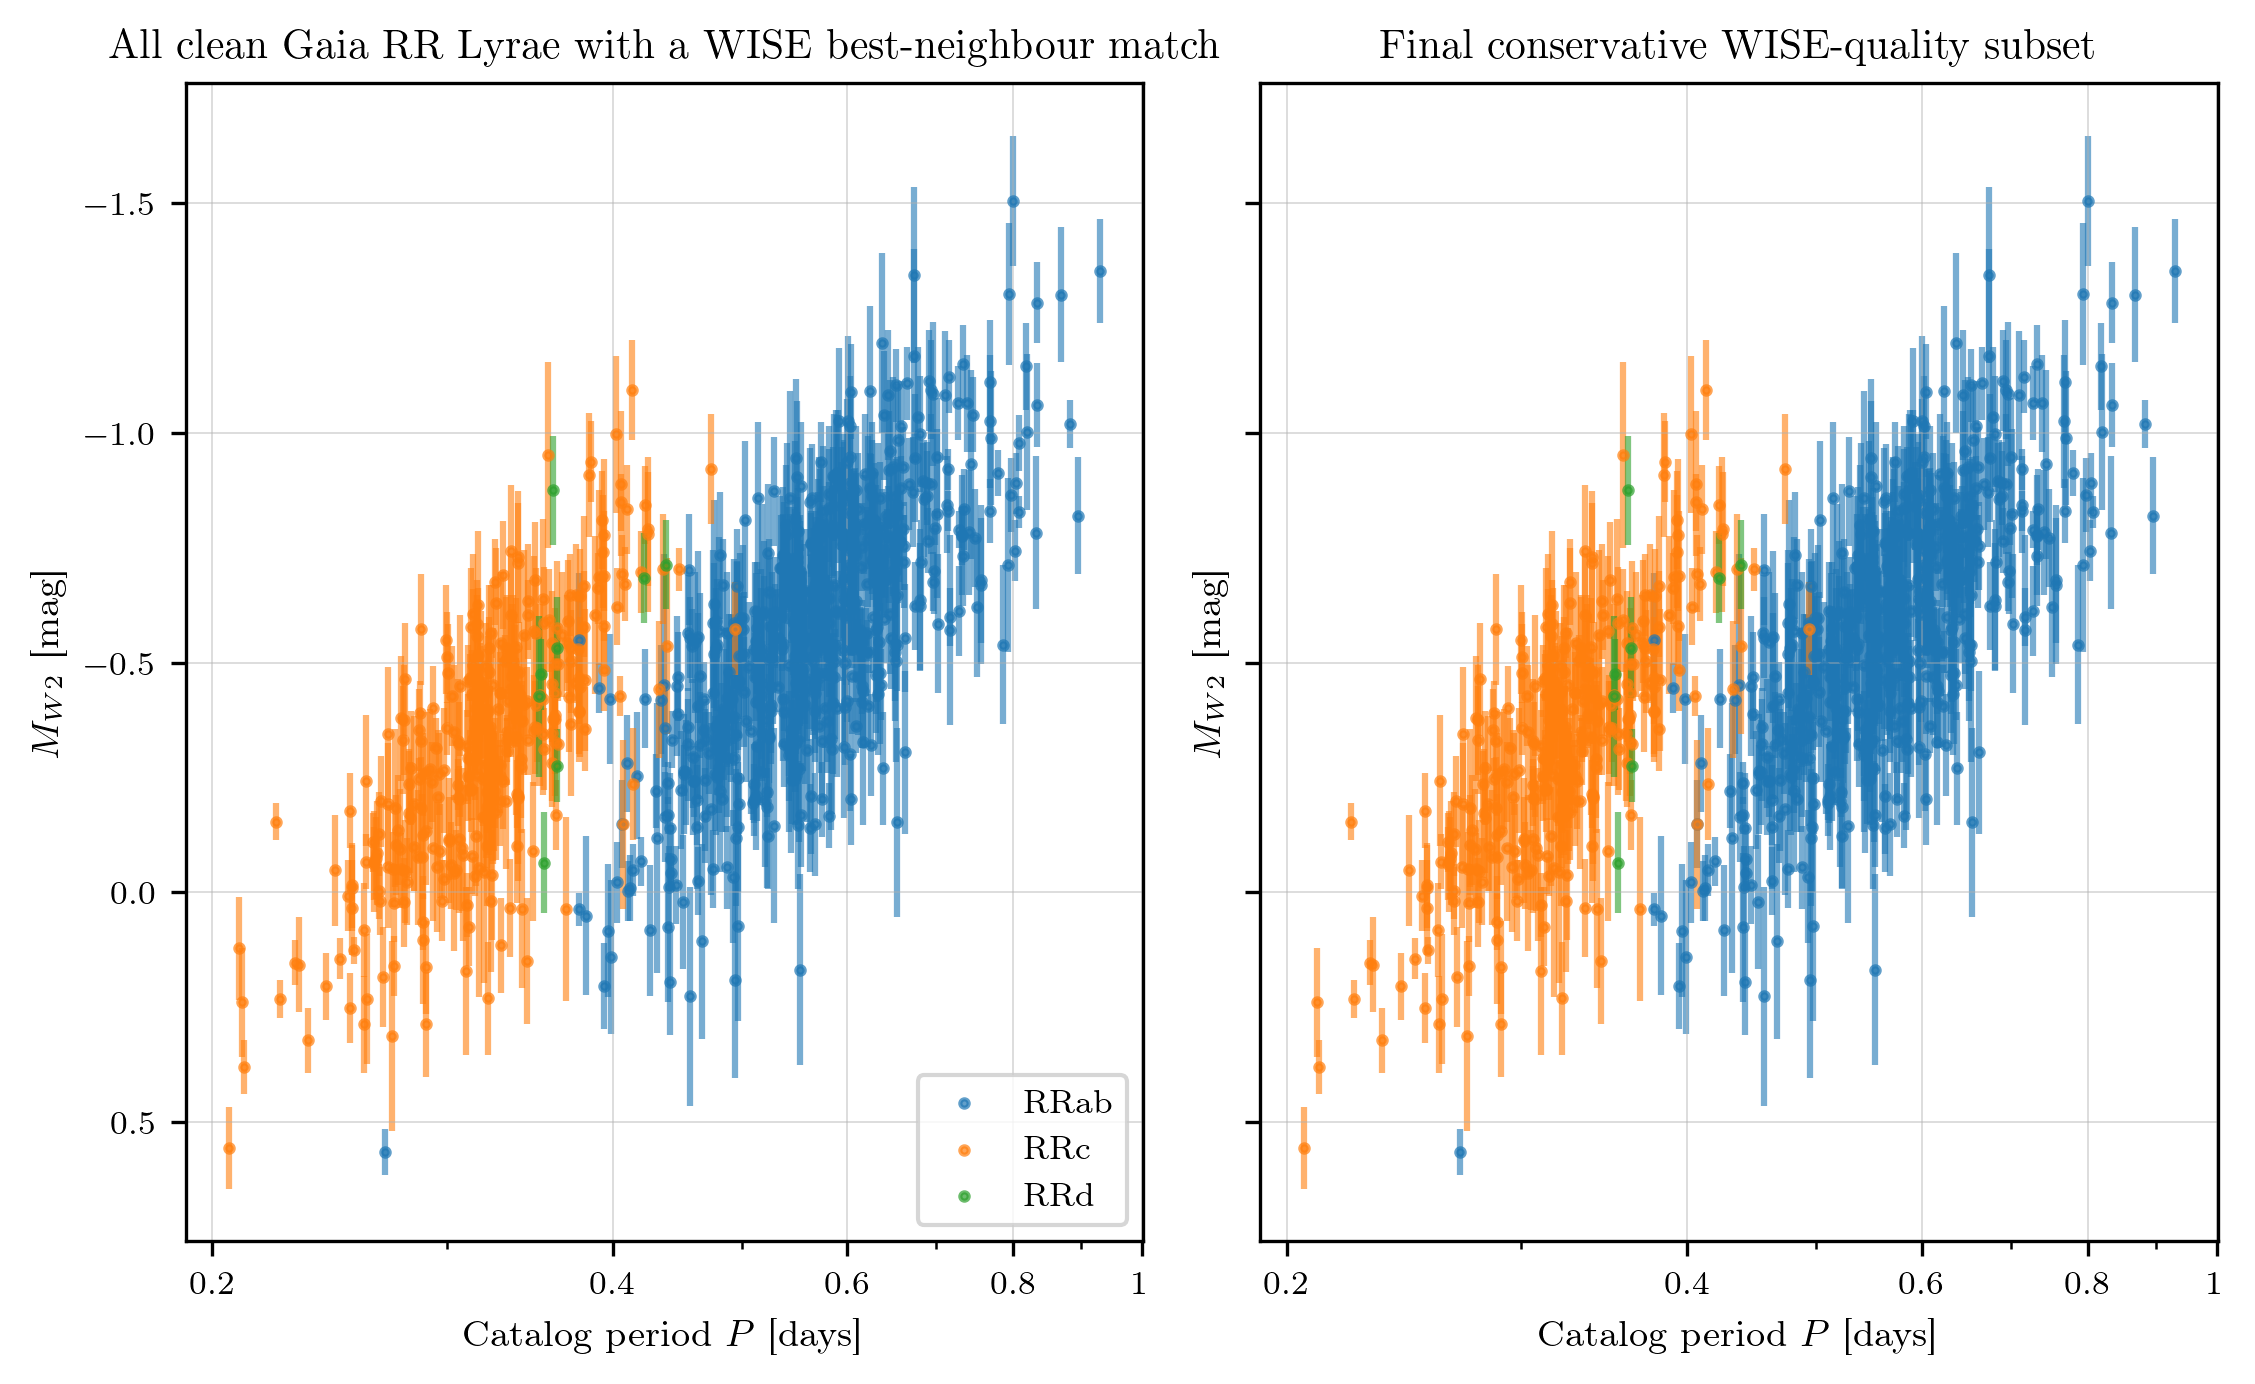

In [14]:
matched_period = np.asarray(matched_best_neighbour_rr_data["rrlyrae_representative_period"], dtype=float)
wise_period = np.asarray(wise_clean_data["rrlyrae_representative_period"], dtype=float)
matched_classes = _col_as_str(matched_best_neighbour_rr_data["best_classification"])
wise_classes = _col_as_str(wise_clean_data["best_classification"])

axes = plot_period_abs_mag_comparison(
    matched_period,
    _col_as_float(matched_best_neighbour_rr_data["M_W2"]),
    _col_as_float(matched_best_neighbour_rr_data["sigma_M_W2"]),
    matched_classes,
    wise_period,
    _col_as_float(wise_clean_data["M_W2"]),
    _col_as_float(wise_clean_data["sigma_M_W2"]),
    wise_classes,
)
axes[0].set_title("All clean Gaia RR Lyrae with a WISE best-neighbour match")
axes[1].set_title("Final conservative WISE-quality subset")
for ax in axes:
    ax.set_ylabel(r"$M_{W2}$ [mag]")
plt.show()


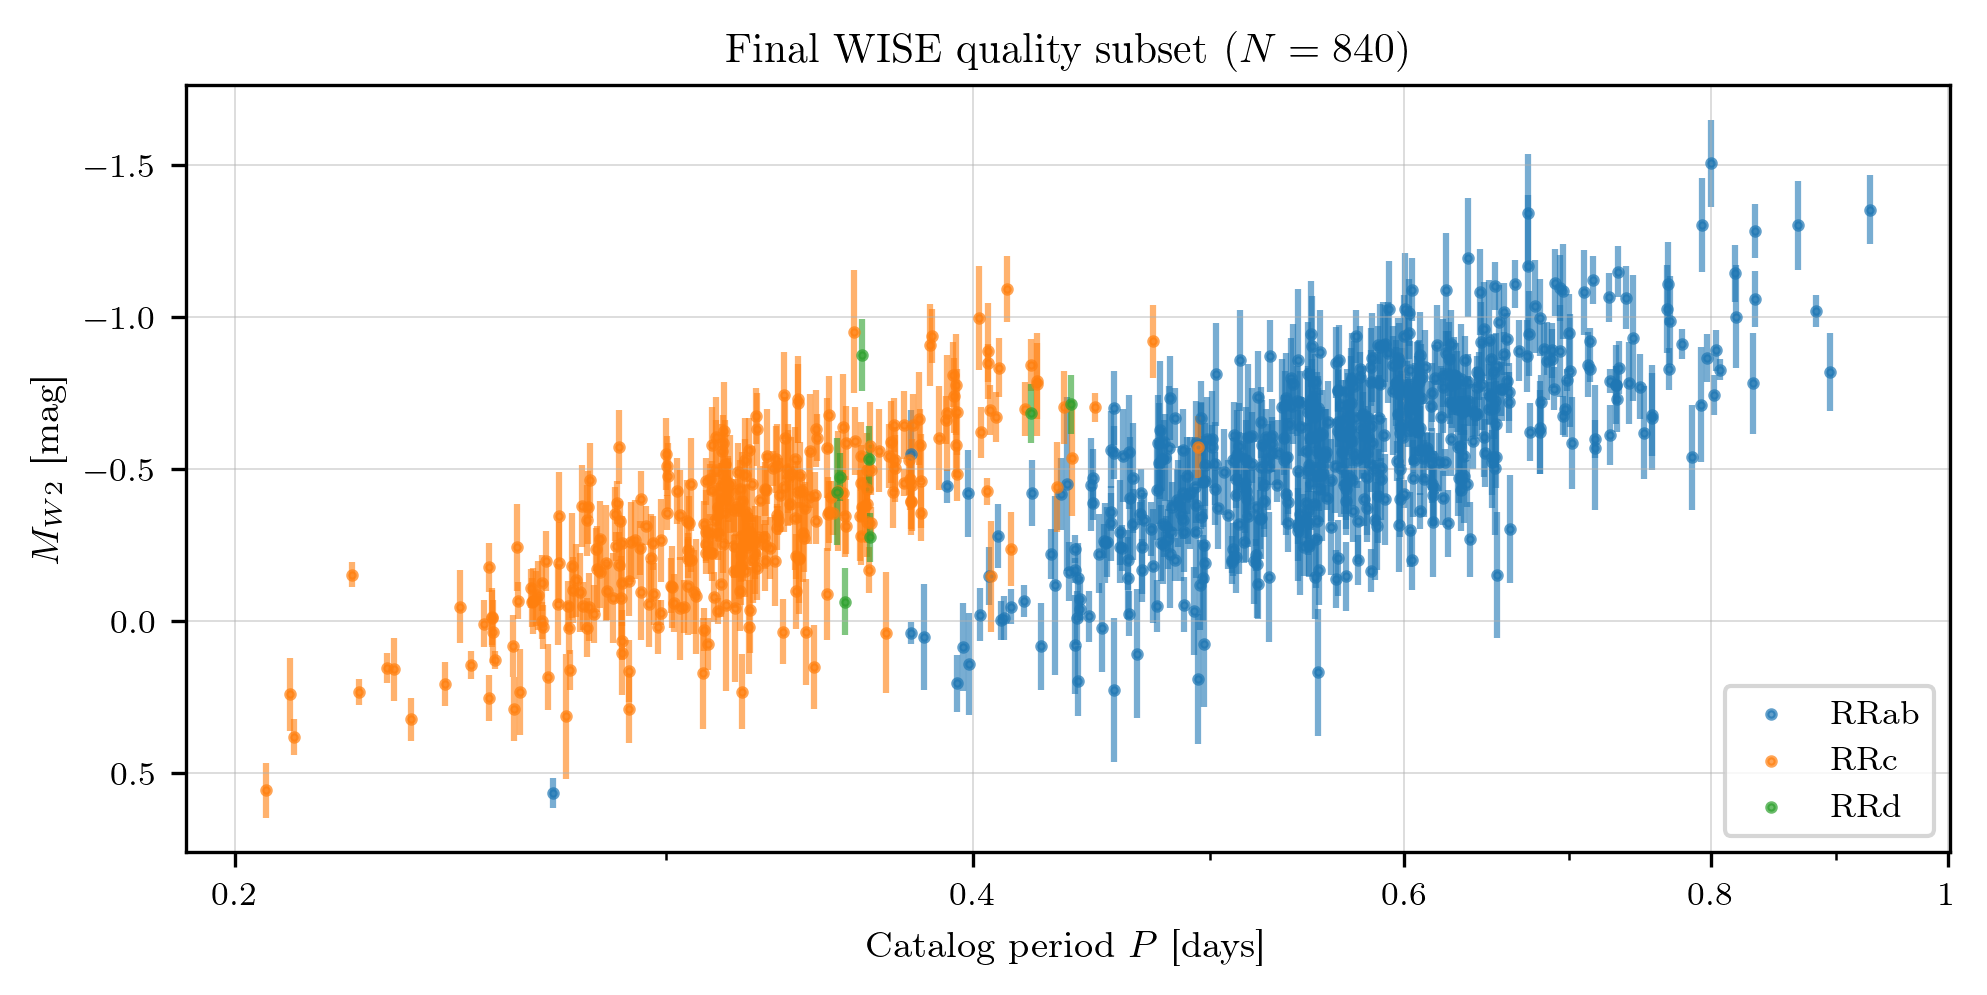

In [15]:
ax = plot_period_abs_mag(
    wise_period,
    _col_as_float(wise_clean_data["M_W2"]),
    _col_as_float(wise_clean_data["sigma_M_W2"]),
    wise_classes,
)
ax.set_ylabel(r"$M_{W2}$ [mag]")
ax.set_title(rf"Final WISE quality subset ($N={len(wise_clean_data)}$)")
plt.show()

## Why Keep RRab and RRc Separate, and Why Exclude RRd?

The same subclass logic from `02-02.ipynb` applies here. Gaia DR3 treats **RRab**, **RRc**, and **RRd** as distinct RR Lyrae subclasses because they correspond to different pulsation behaviour and light-curve morphology ([Clementini et al. 2023](https://www.aanda.org/articles/aa/full_html/2023/06/aa43964-22/aa43964-22.html)). RRab stars are fundamental-mode pulsators, RRc stars are first-overtone pulsators, and RRd stars are double-mode stars that simultaneously excite both the fundamental and first overtone.

That distinction matters for infrared calibration too. Recent distance-calibration work argues that RRab and RRc should generally be calibrated separately rather than forced into a single mixed relation, even after overtone transformations, because residual subclass structure can remain ([Narloch et al. 2024](https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html); [Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776)). RRd is different again: it is a distinct double-mode problem, and recent work uses RRd-specific distance relations involving both the period and the period ratio ([Shi et al. 2023](https://doi.org/10.1038/s41550-023-02011-y)).

The fit therefore uses only **RRab** and **RRc**. RRd stars are counted and shown in the sample accounting, but they are not folded into either subclass fit.


In [16]:
wise_rrab_data = wise_clean_data[_col_as_str(wise_clean_data["best_classification"]) == "RRab"]
wise_rrc_data = wise_clean_data[_col_as_str(wise_clean_data["best_classification"]) == "RRc"]
wise_rrd_data = wise_clean_data[_col_as_str(wise_clean_data["best_classification"]) == "RRd"]

rrab_ctx = build_w2_context(wise_rrab_data, "RRab")
rrc_ctx = build_w2_context(wise_rrc_data, "RRc")

table.Table(
    rows=[
        {"class": "RRab", "N_fit": rrab_ctx.n},
        {"class": "RRc", "N_fit": rrc_ctx.n},
        {"class": "RRd excluded", "N": len(wise_rrd_data)},
    ]
)


class,N_fit,N
str12,int64,int64
RRab,527,--
RRc,305,--
RRd excluded,--,8


## Bayesian Model for the WISE $W2$ Relation

The statistical model follows the same structure as `02-02.ipynb`, but with $M_{W2}$ in place of $M_G$.

For each subclass separately, define

\[
 x = \log_{10}(P/\mathrm{day}), \qquad x_c = x - \langle x \rangle_{\rm class},
\]

and fit

\[
 M_{W2} = a\,x_c + b.
\]

The centering step is purely statistical. It makes the intercept easier to interpret numerically, because $b$ becomes the mean $M_{W2}$ at the **sample mean log-period** of that subclass rather than at $P=1\,\mathrm{day}$. That usually reduces posterior covariance between slope and intercept.

The total variance in the likelihood is

\[
 \sigma_{{\rm tot},i}^2 = \sigma_{M_{W2},i}^2 + \sigma_{\rm scatter}^2 + a^2\sigma_{\log P,i}^2,
\]

where:

- $\sigma_{M_{W2},i}$ is the measurement uncertainty on the inferred absolute WISE magnitude,
- $\sigma_{\rm scatter}$ is the intrinsic scatter of the subclass relation,
- $\sigma_{\log P,i} = \sigma_{P,i}/(P_i\ln 10)$ is the first-order propagated period uncertainty.

This is still an **absolute-magnitude-space** model. As discussed in `02-02.ipynb`, the Gaia literature more commonly treats the final calibration problem in parallax space or in hierarchical Bayesian form, because that avoids the main inverse-parallax biases directly ([Gaia Collaboration et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html); [Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596); [Delgado et al. 2019](https://www.aanda.org/articles/aa/full_html/2019/03/aa32945-18/aa32945-18.html)). The point here is to keep the same pedagogical modelling approach as `02-02.ipynb` so that the change of bandpass is isolated cleanly.


### Priors

The priors are the same weakly informative choices used in `02-02.ipynb`:

- slope: $a \sim \mathcal{N}(0, 5)$,
- intercept: $b \sim \mathcal{N}(\mathrm{median}(M_{W2}), 1\,\mathrm{mag})$,
- intrinsic scatter: $\sigma_{\rm scatter} \sim \mathrm{HalfNormal}(0.5\,\mathrm{mag})$.

These are not meant to dominate the fit. They are only there to regularize the model and make the numerical geometry of the posterior well behaved.


In [17]:
rrab_sampler = fit_w2_nuts(rrab_ctx, seed=128)
rrab_sampler.acceptance_rate

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


0.8257955911423179

In [18]:
rrab_summary = table.Table(rows=[w2_posterior_summary_row("RRab", "WISE $W2$", rrab_sampler, rrab_ctx.n)])
rrab_summary

class,band,N_fit,acceptance,a,a_minus,a_plus,b,b_minus,b_plus,sigma_scatter,sigma_minus,sigma_plus
str4,str9,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRab,WISE $W2$,527,0.826,-2.9845,0.11,0.1123,-0.5683,0.0082,0.0079,0.1475,0.0069,0.0074


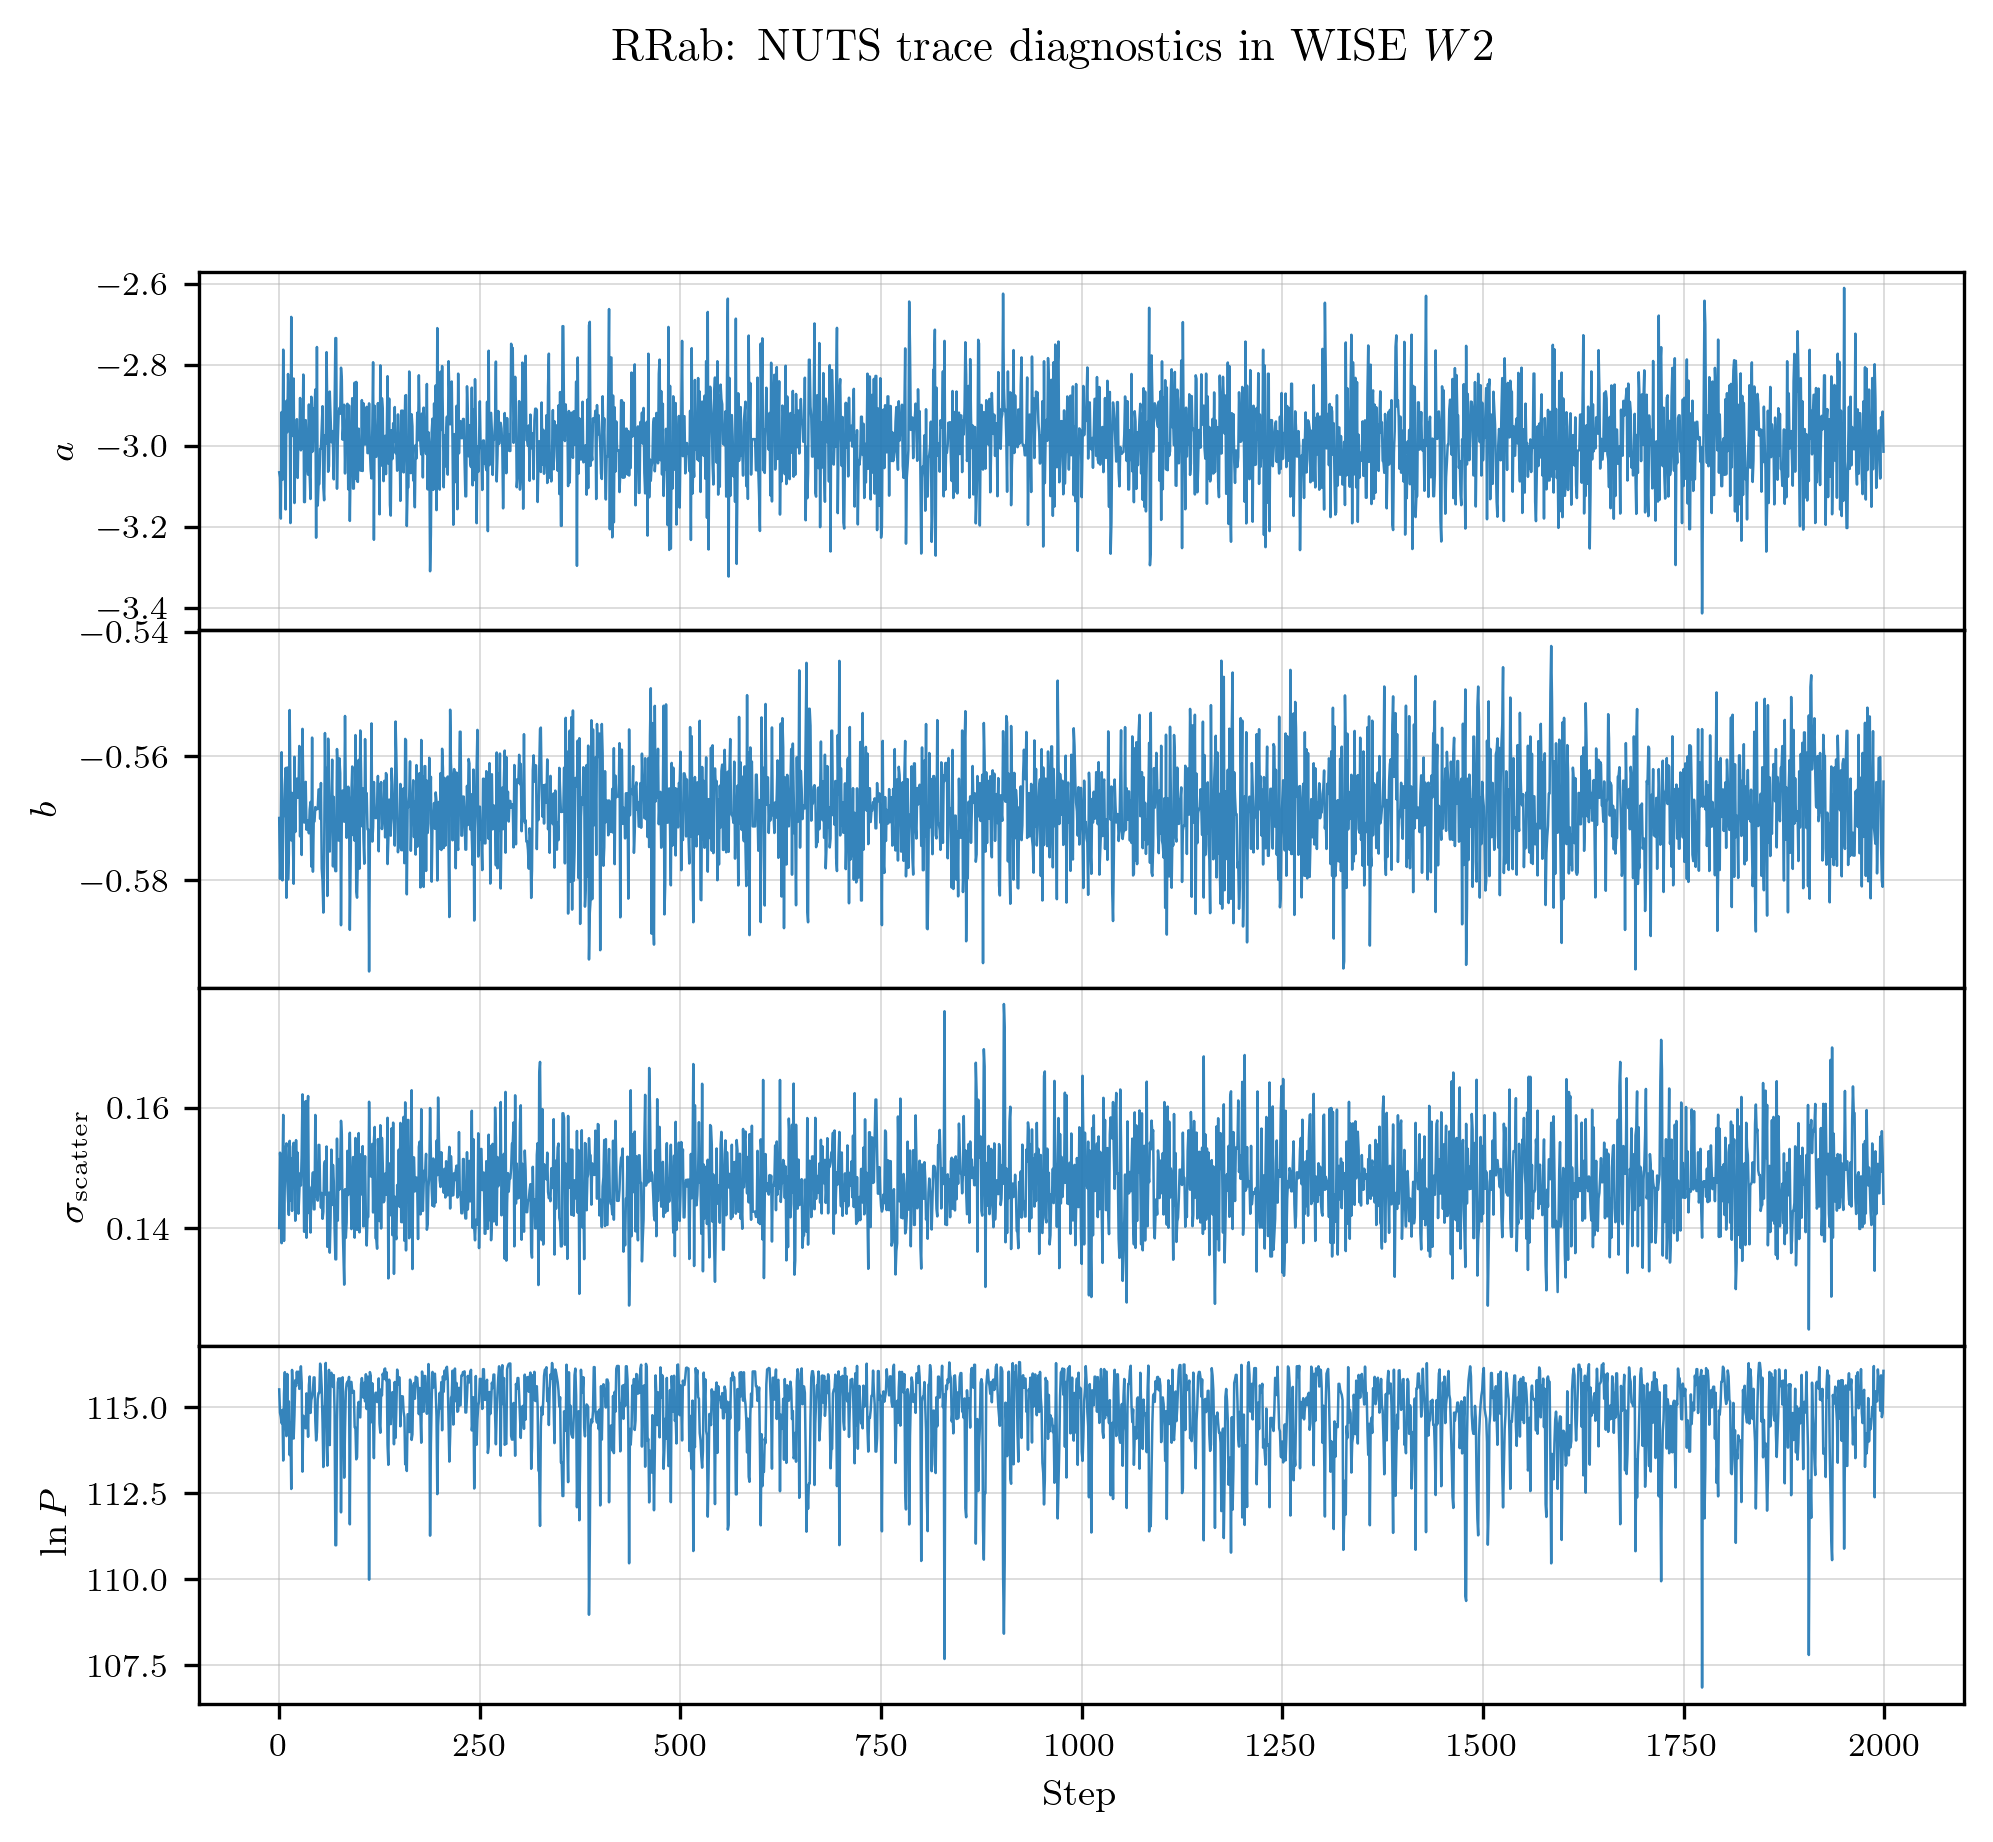

In [19]:
axes = plot_trace(
    rrab_sampler.samples,
    rrab_sampler.log_probs,
    rrab_sampler.param_labels,
    rrab_sampler.n_burn,
    color=mcmc_sampler_color("RRab", "native"),
)
axes[0].figure.suptitle("RRab: NUTS trace diagnostics in WISE $W2$", y=1.01)
plt.show()

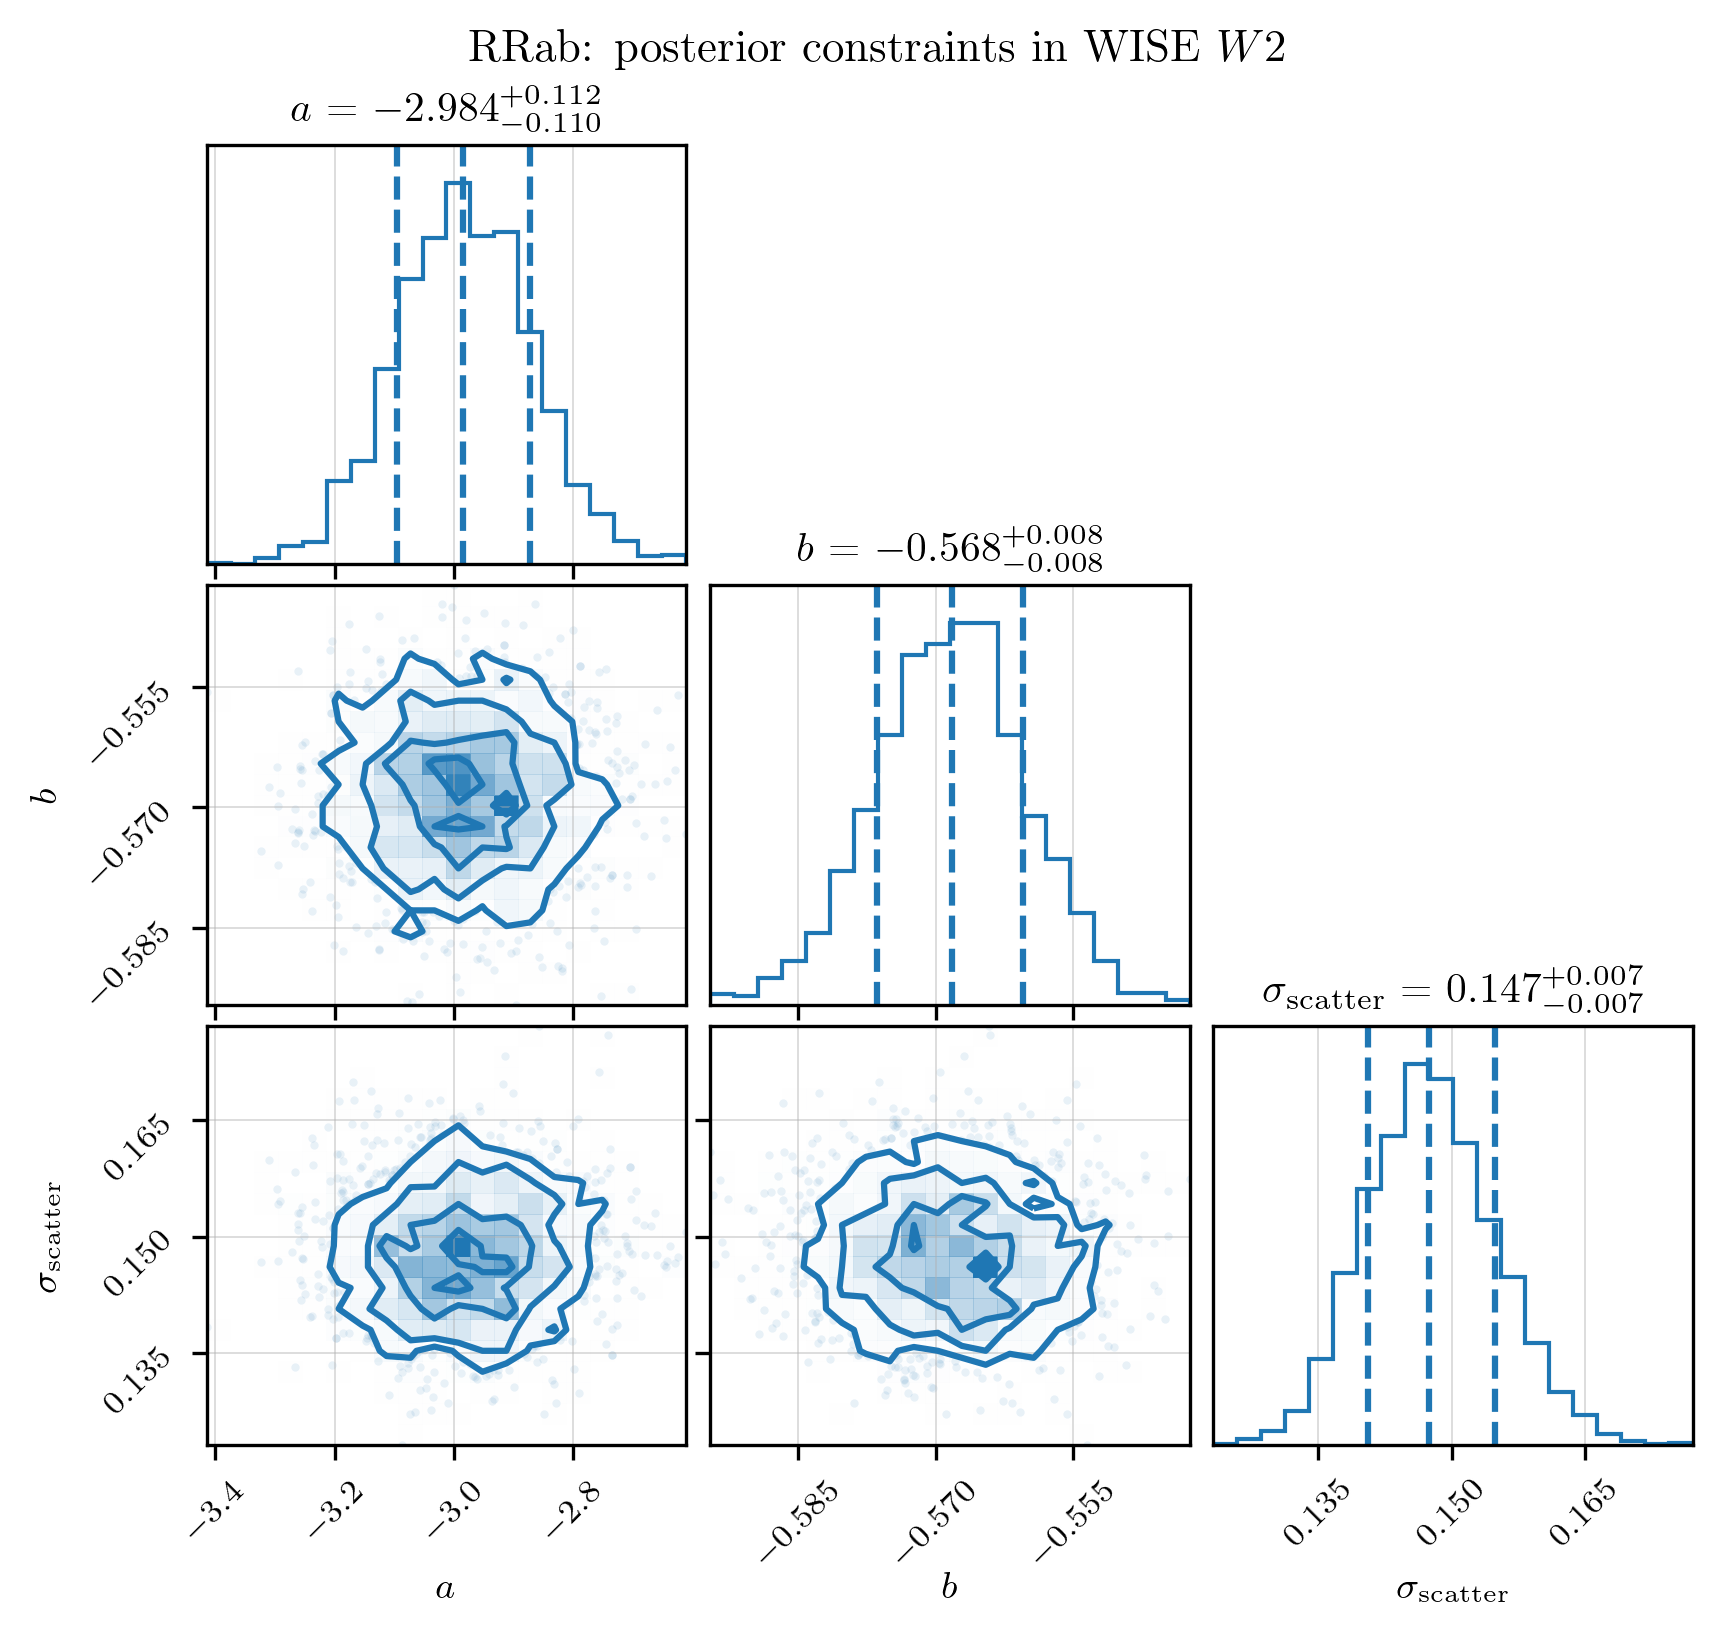

In [20]:
fig = plot_corner(
    rrab_sampler,
    labels=DISPLAY_LABELS,
    color=mcmc_sampler_color("RRab", "native"),
)
fig.suptitle("RRab: posterior constraints in WISE $W2$", y=1.02)
plt.show()

The trace plot and corner plot are diagnostic rather than decorative. The trace should look approximately stationary, without a long transient trend or obvious long-lived mode switching, and the corner plot shows how strongly the slope, intercept, and intrinsic scatter covary. Because this notebook uses a single-chain wrapper, these diagnostics are useful but not exhaustive. They are still enough to reveal obvious pathologies.


To mirror the handout's optical workflow more directly, I also show 50 random posterior mean relations over the data before the predictive envelope. That line-sample view isolates uncertainty in the mean W2 relation, while the predictive envelope includes both measurement noise and the fitted intrinsic scatter.

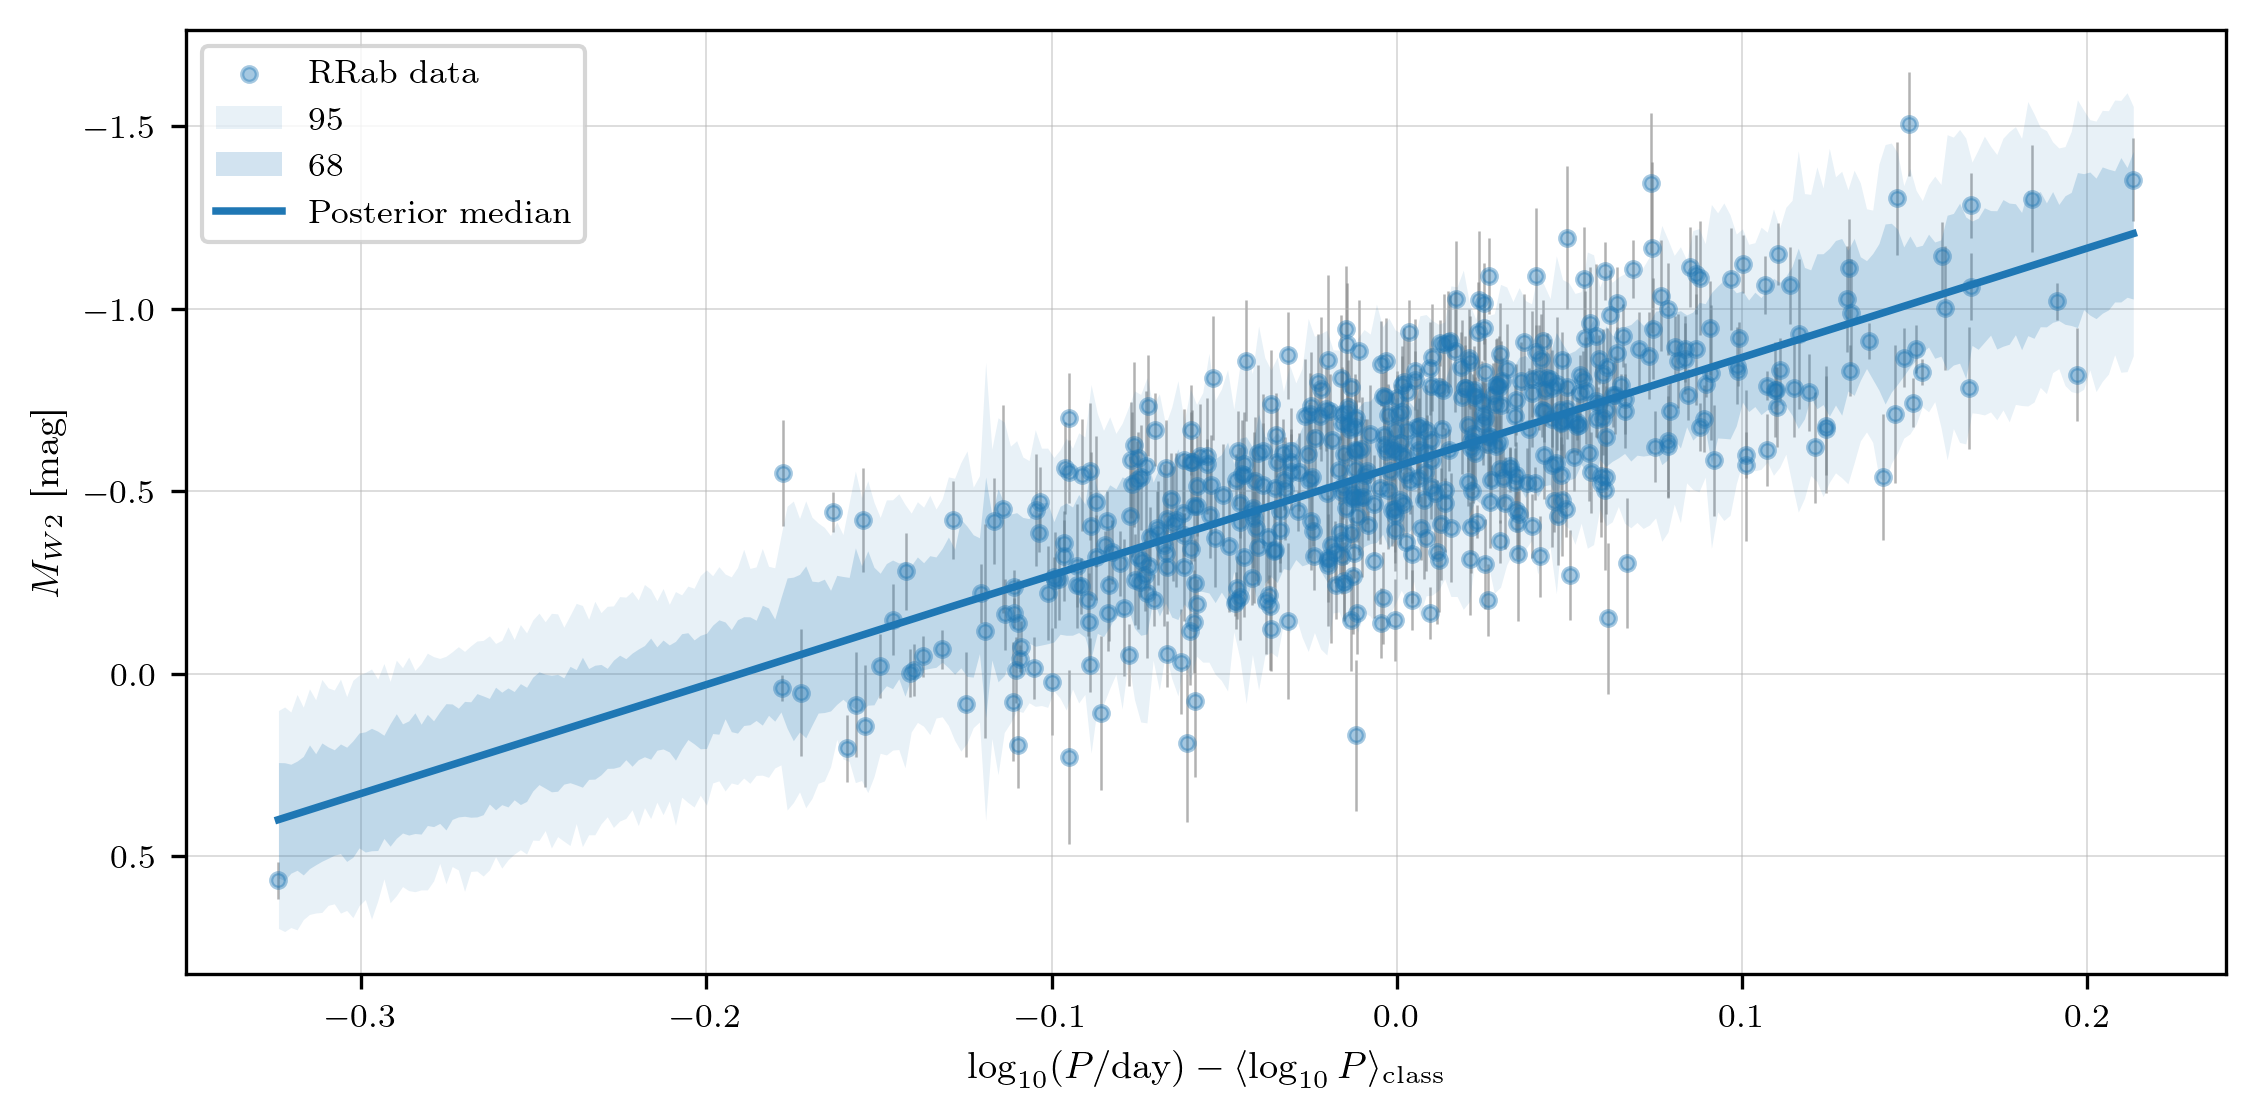

In [21]:
ax = plot_w2_posterior_predictive(
    rrab_ctx,
    rrab_sampler.samples[rrab_sampler.n_burn:],
    save_name="fig_wise_pl_rrab.pdf",
)
plt.show()

In [22]:
rrc_sampler = fit_w2_nuts(rrc_ctx, seed=256)
rrc_sampler.acceptance_rate

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


0.8251879357909545

In [23]:
rrc_summary = table.Table(rows=[w2_posterior_summary_row("RRc", "WISE $W2$", rrc_sampler, rrc_ctx.n)])
rrc_summary

class,band,N_fit,acceptance,a,a_minus,a_plus,b,b_minus,b_plus,sigma_scatter,sigma_minus,sigma_plus
str3,str9,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRc,WISE $W2$,305,0.825,-3.232,0.1547,0.1621,-0.3125,0.0096,0.01,0.135,0.0086,0.0087


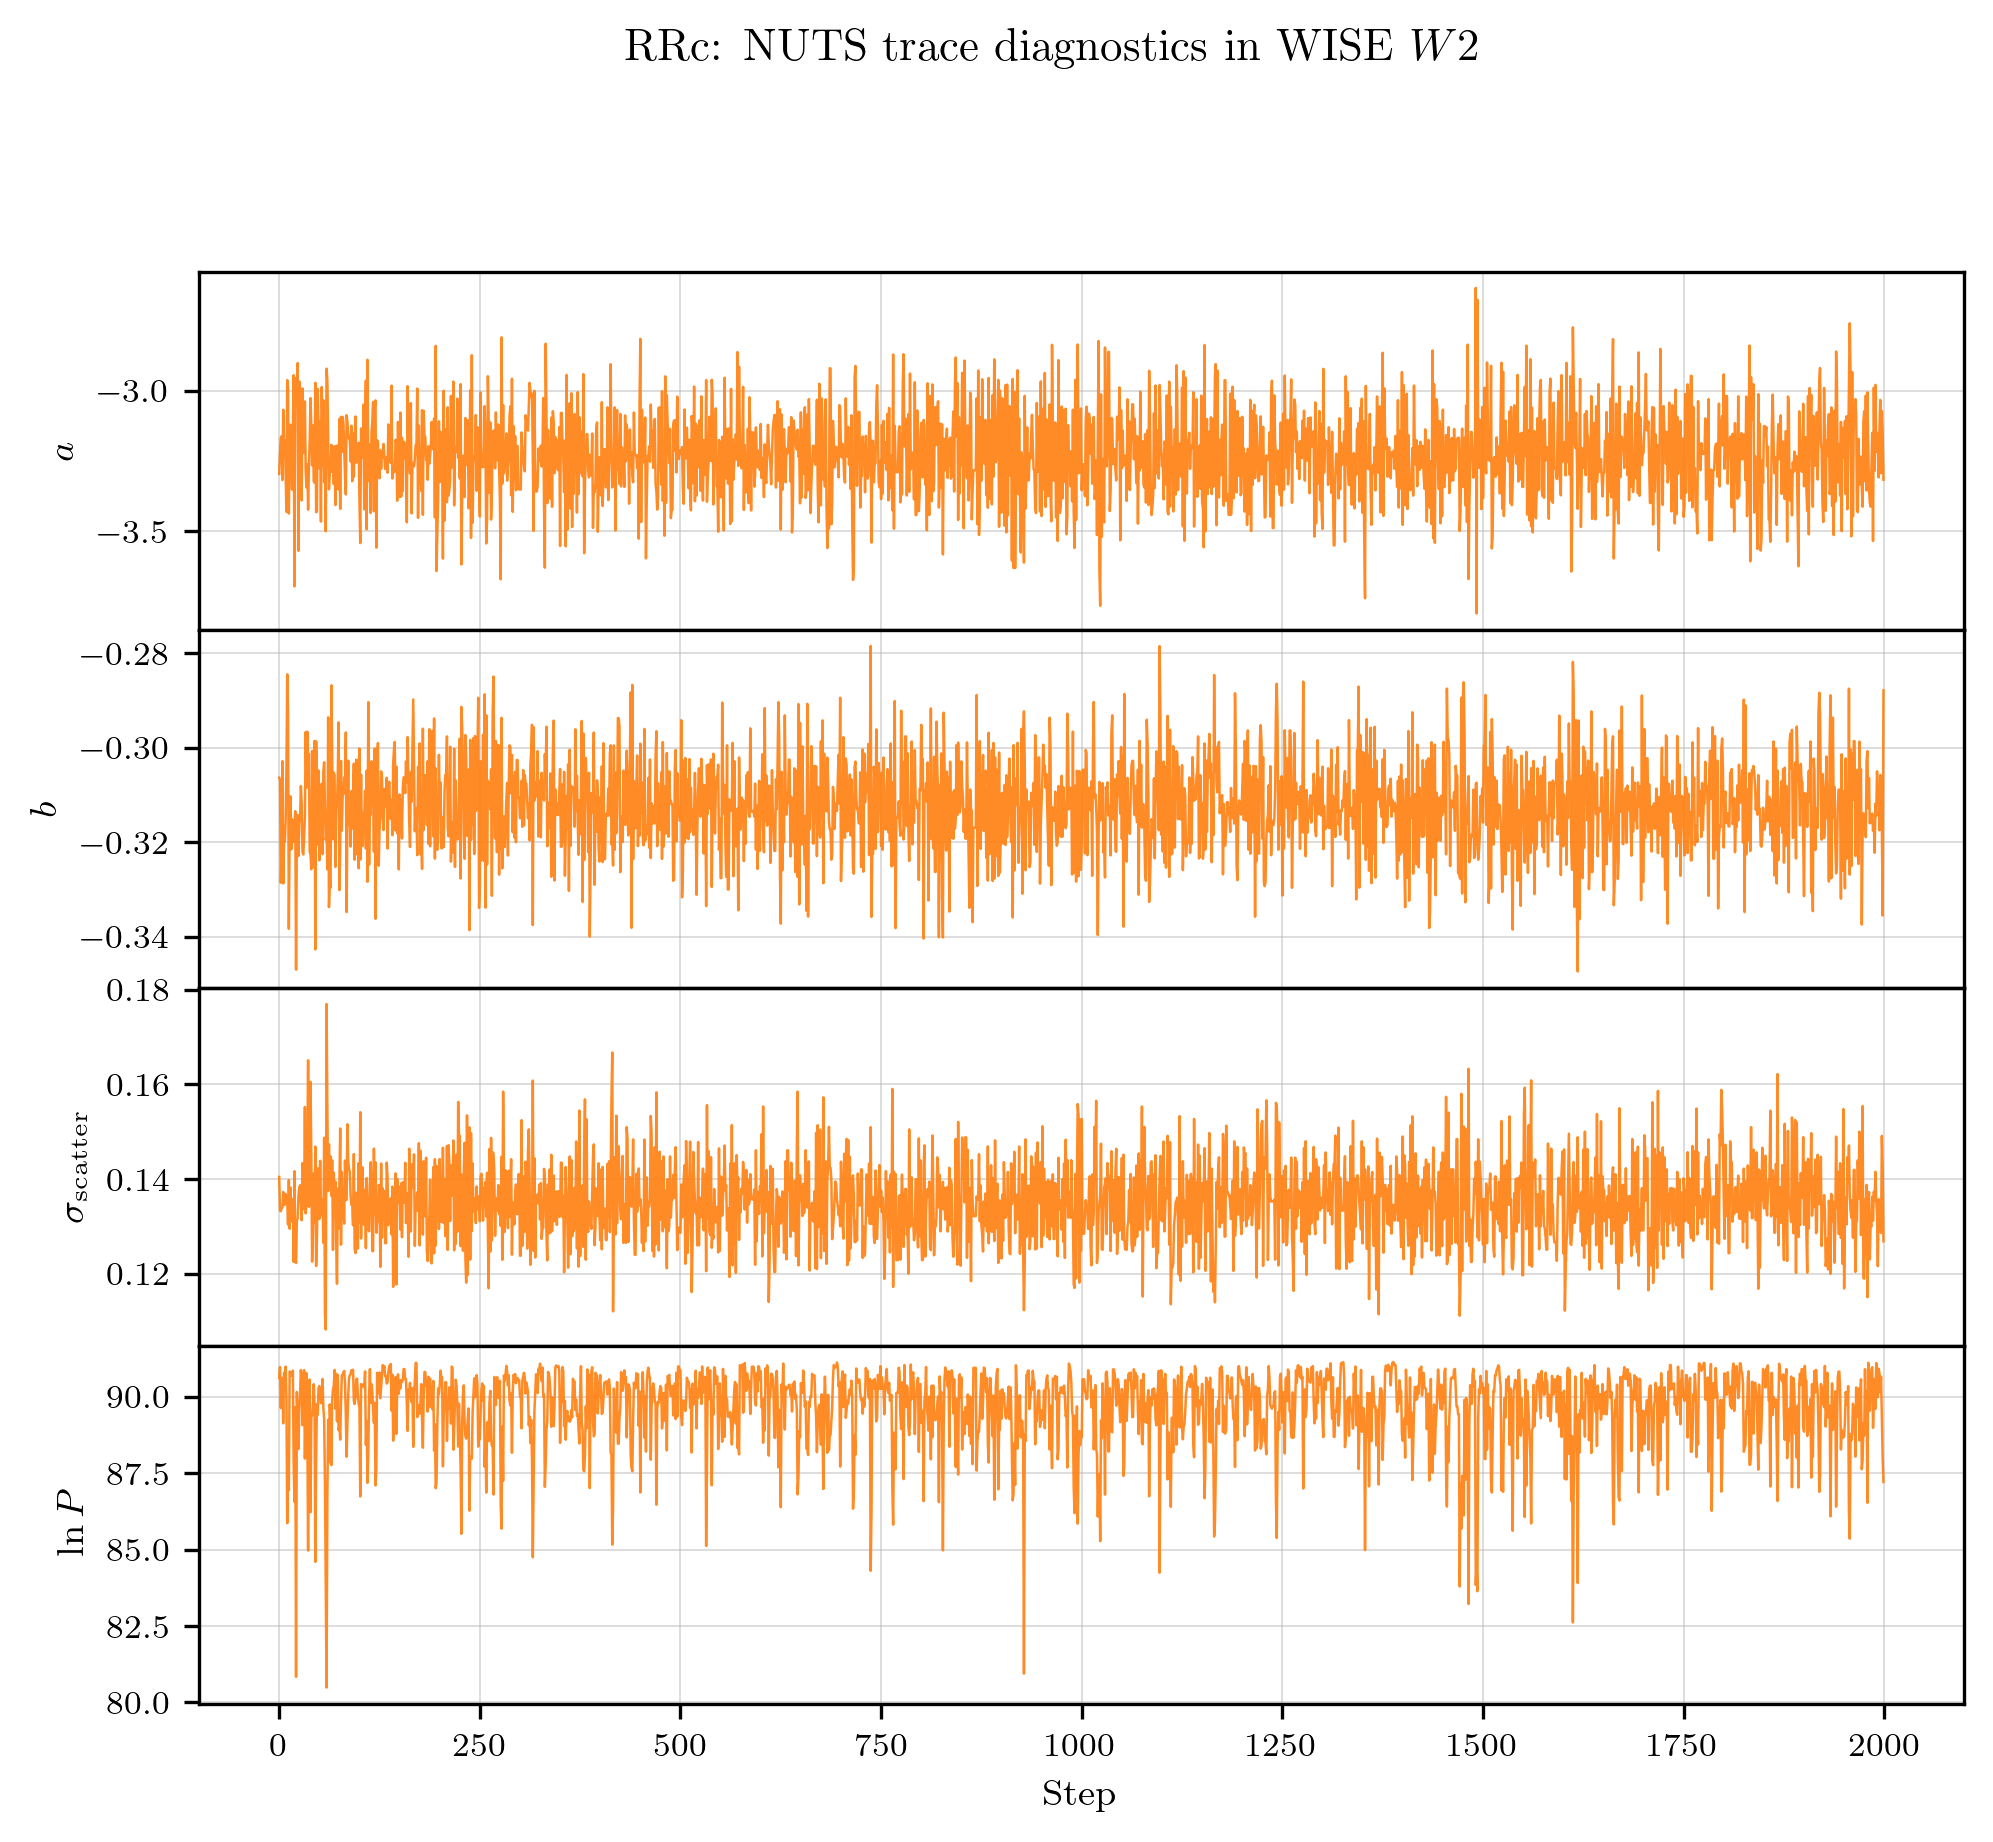

In [24]:
axes = plot_trace(
    rrc_sampler.samples,
    rrc_sampler.log_probs,
    rrc_sampler.param_labels,
    rrc_sampler.n_burn,
    color=mcmc_sampler_color("RRc", "native"),
)
axes[0].figure.suptitle("RRc: NUTS trace diagnostics in WISE $W2$", y=1.01)
plt.show()

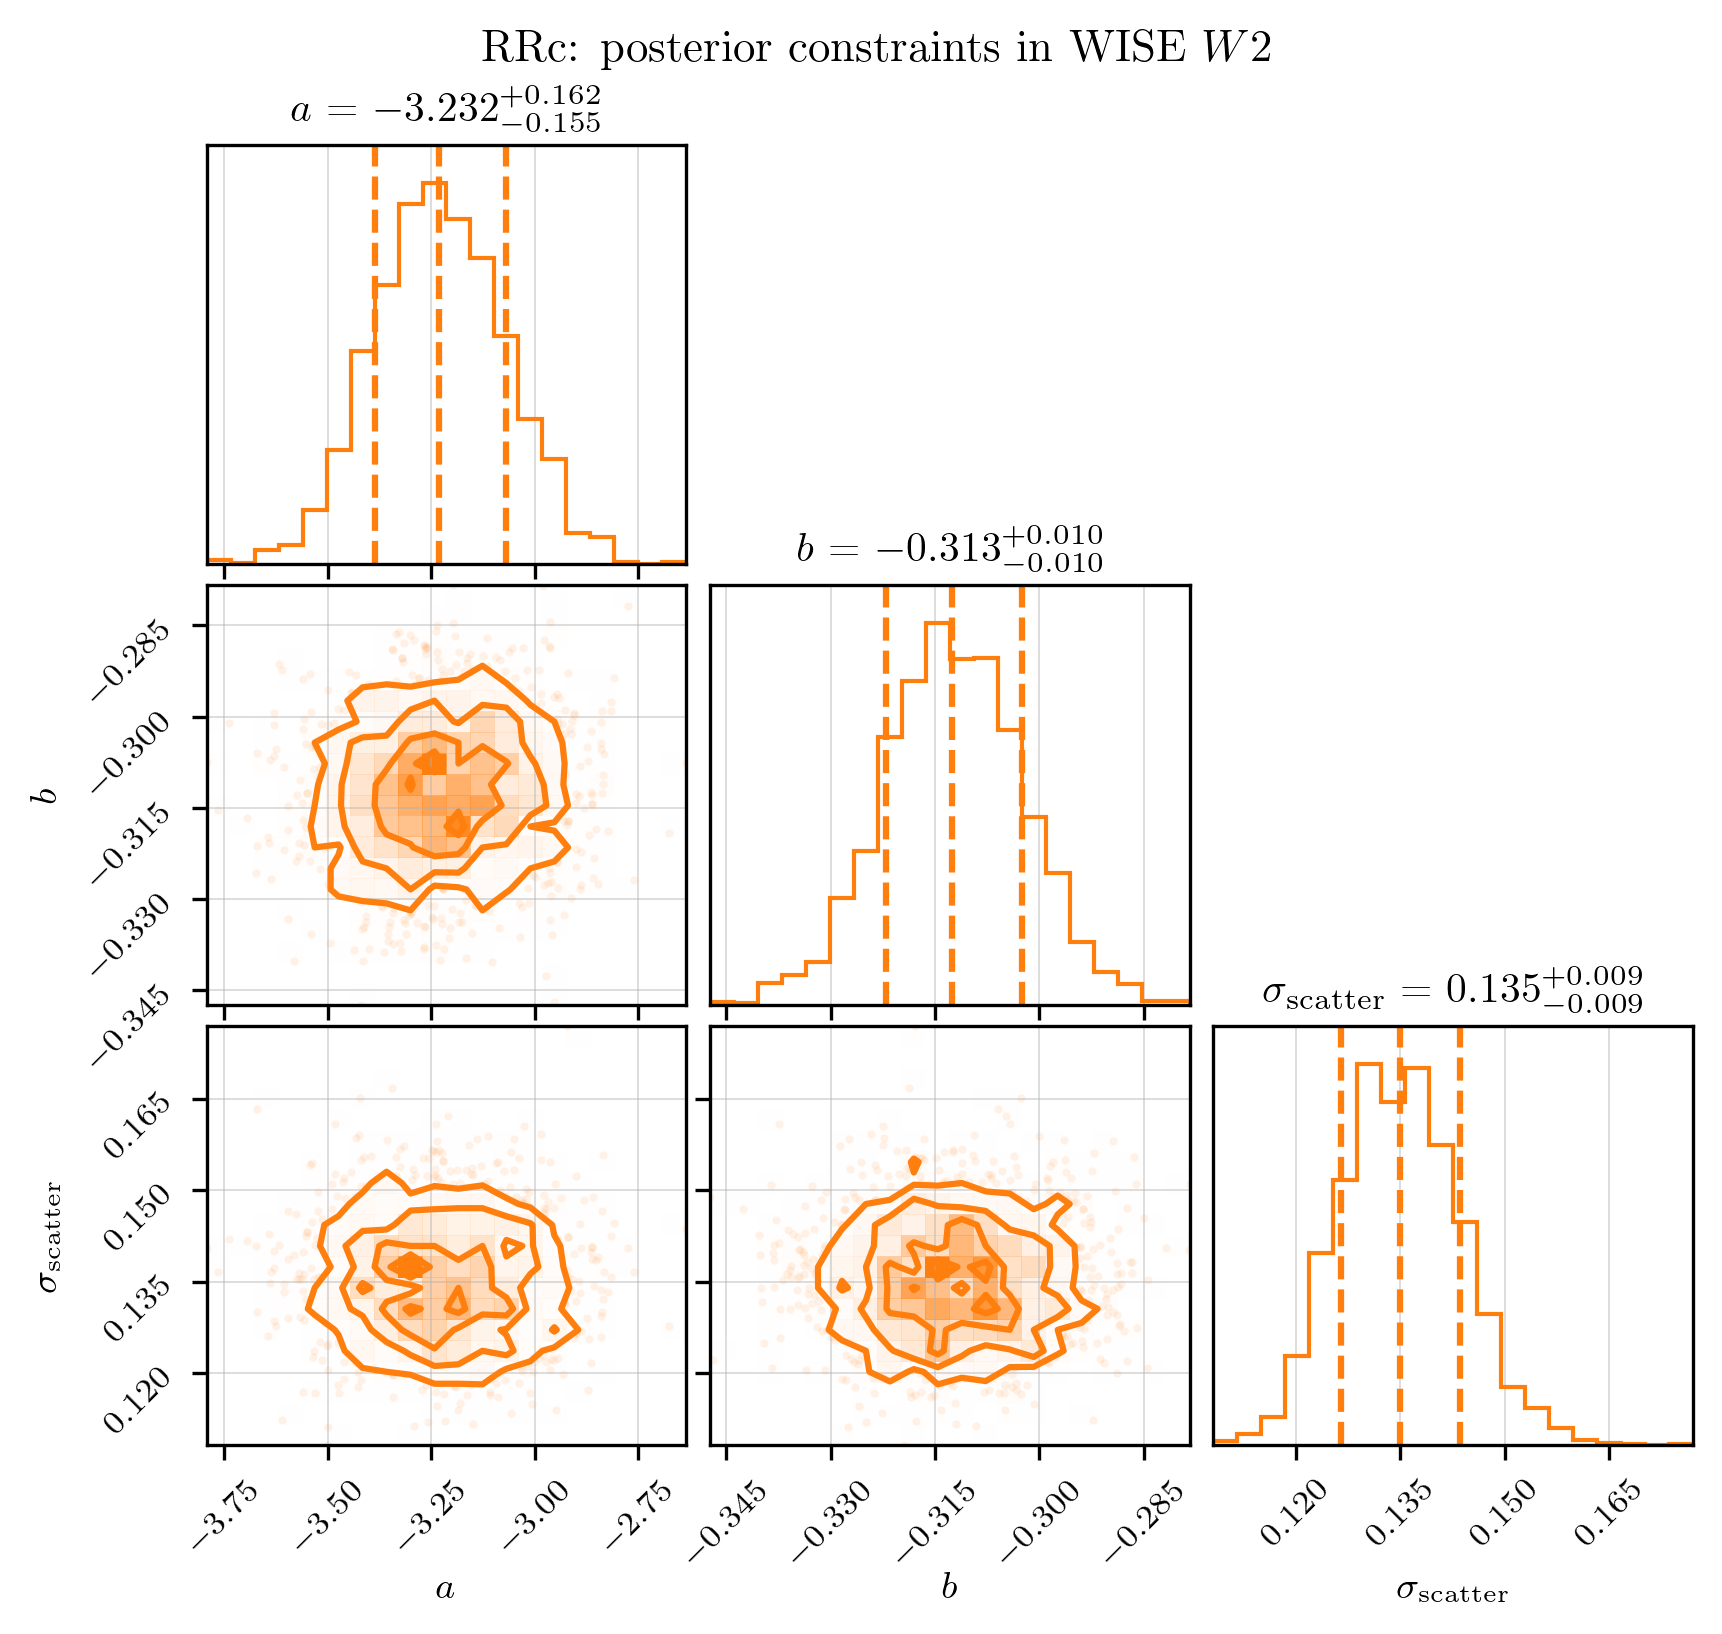

In [25]:
fig = plot_corner(
    rrc_sampler,
    labels=DISPLAY_LABELS,
    color=mcmc_sampler_color("RRc", "native"),
)
fig.suptitle("RRc: posterior constraints in WISE $W2$", y=1.02)
plt.show()

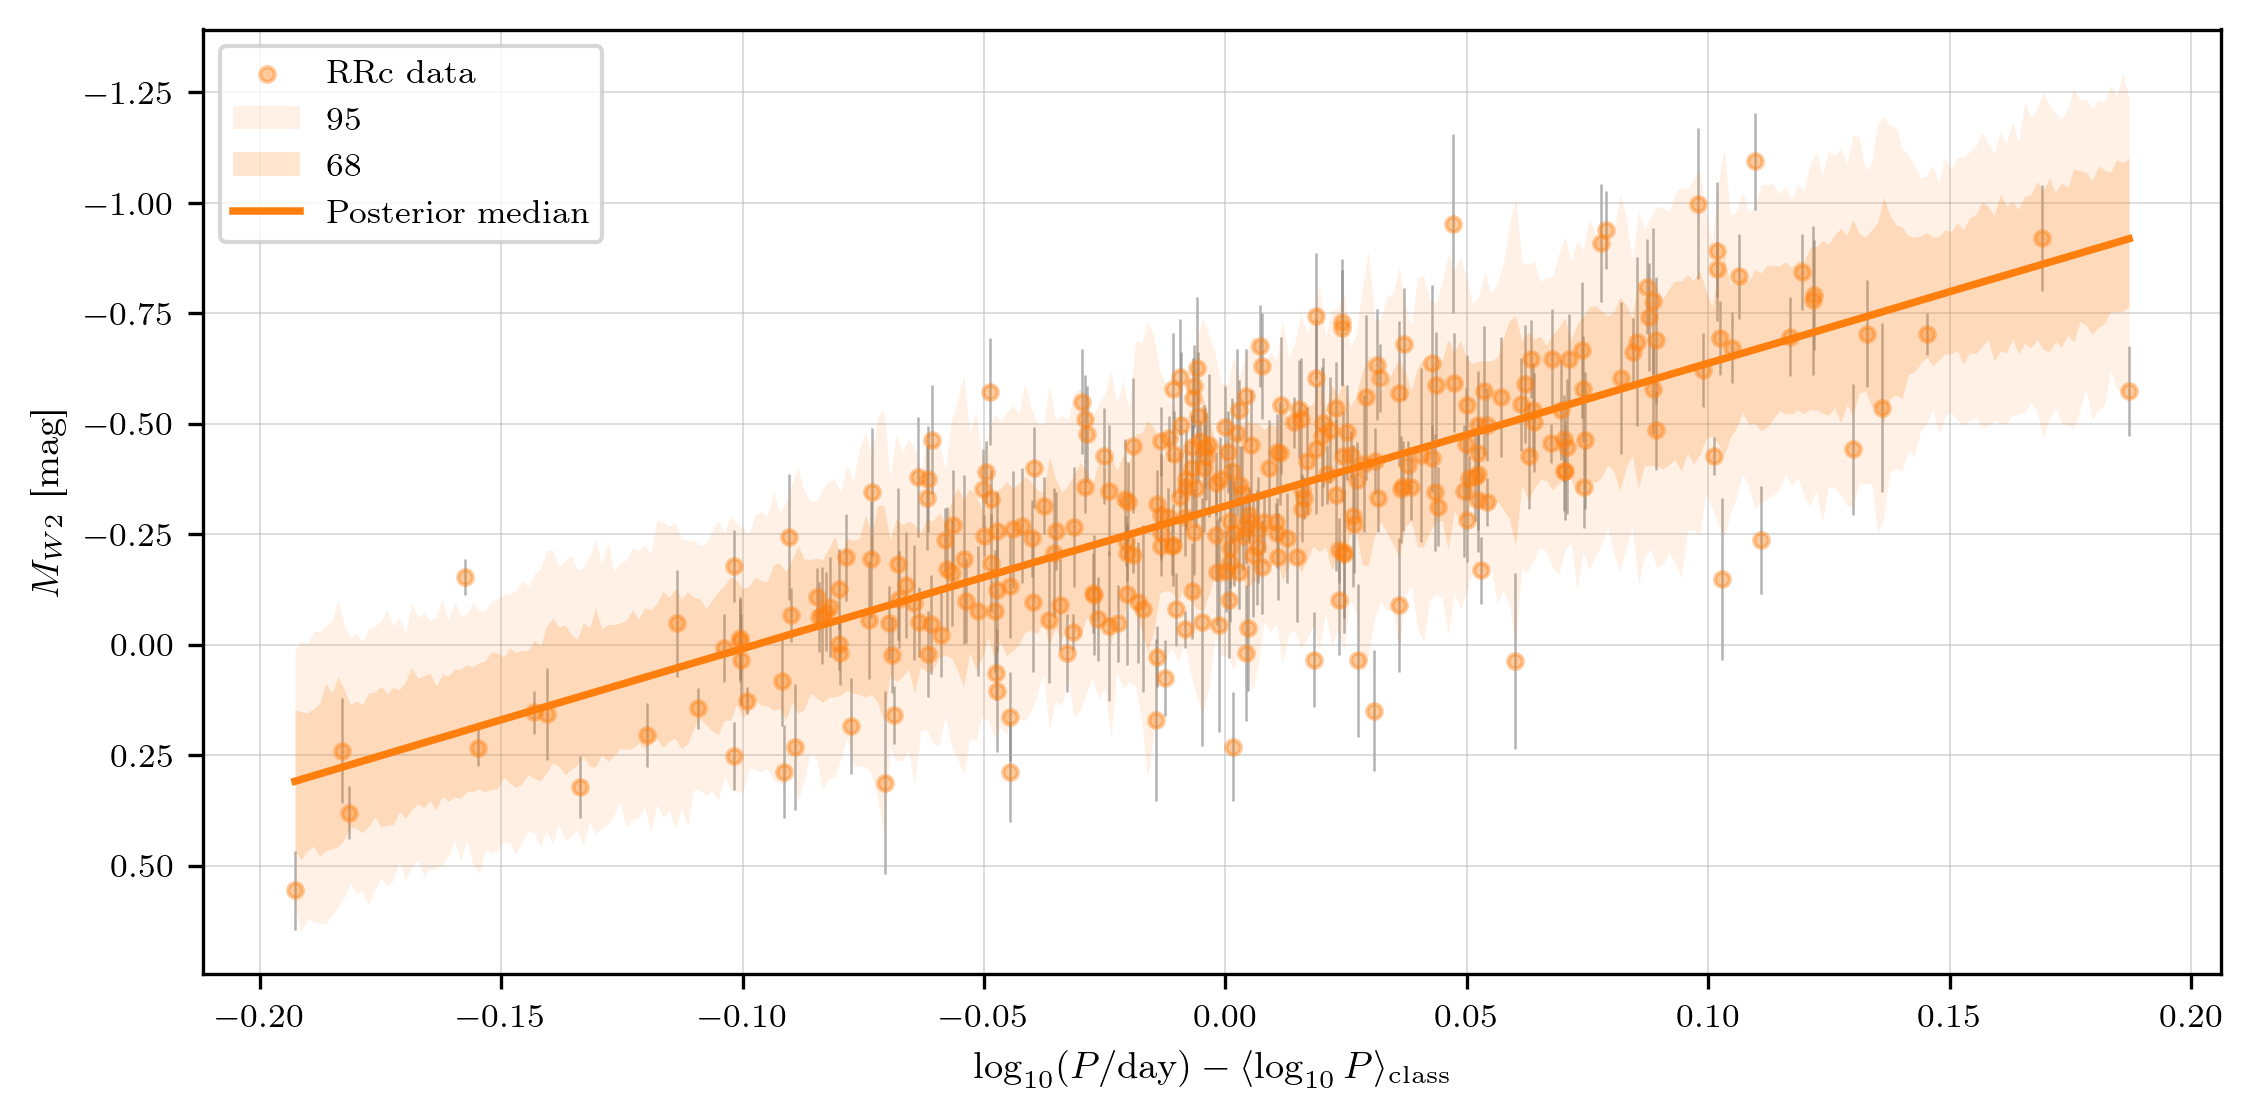

In [26]:
ax = plot_w2_posterior_predictive(
    rrc_ctx,
    rrc_sampler.samples[rrc_sampler.n_burn:],
    save_name="fig_wise_pl_rrc.pdf",
)
plt.show()

## Optical vs Near-Infrared Comparison

The clean optical Gaia $G$ fits from `02-02.ipynb` have already been summarized in `rrlyrae_optical_pl_comparison_data.npz`. That handoff artifact stores the subclass-specific Gaia $G$ posterior predictive summaries in raw $\log_{10}(P/\mathrm{day})$ space, so we can compare them directly to the new WISE $W2$ fits without re-running the optical notebook.

The scientifically meaningful quantities to compare are:

- the **slope magnitude** $|a|$, which answers whether the relation is steeper in one band than the other,
- the inferred **intrinsic scatter**, which tells us whether one band gives a tighter subclass relation,
- the predictive envelopes, which show whether the full spread of the fitted relation is consistent with the data.

The intercepts are less useful as a cross-band diagnostic because:

- the predictors are centered within each subclass,
- the photometric zero-points differ between bands,
- optical and infrared magnitudes respond to different stellar-physics and extinction terms.


In [27]:
rrab_w2 = build_infrared_pl_comparison_data(rrab_ctx, rrab_sampler.samples)
rrc_w2 = build_infrared_pl_comparison_data(rrc_ctx, rrc_sampler.samples)
wise_comparison = {"RRab": rrab_w2, "RRc": rrc_w2}

comparison_rows = []
for class_label in ("RRab", "RRc"):
    optical = optical_comparison[class_label]
    wise = wise_comparison[class_label]
    comparison_rows.extend(
        [
            {
                "class": class_label,
                "band": "Gaia $G$",
                "N_fit": len(optical.x_obs),
                "a": round(float(optical.slope_q50), 4),
                "a_minus": round(float(optical.slope_q50 - optical.slope_q16), 4),
                "a_plus": round(float(optical.slope_q84 - optical.slope_q50), 4),
                "sigma_scatter": round(float(optical.sigma_scatter_q50), 4),
                "sigma_minus": round(float(optical.sigma_scatter_q50 - optical.sigma_scatter_q16), 4),
                "sigma_plus": round(float(optical.sigma_scatter_q84 - optical.sigma_scatter_q50), 4),
            },
            {
                "class": class_label,
                "band": "WISE $W2$",
                "N_fit": len(wise.x_obs),
                "a": round(float(wise.slope_q50), 4),
                "a_minus": round(float(wise.slope_q50 - wise.slope_q16), 4),
                "a_plus": round(float(wise.slope_q84 - wise.slope_q50), 4),
                "sigma_scatter": round(float(wise.sigma_scatter_q50), 4),
                "sigma_minus": round(float(wise.sigma_scatter_q50 - wise.sigma_scatter_q16), 4),
                "sigma_plus": round(float(wise.sigma_scatter_q84 - wise.sigma_scatter_q50), 4),
            },
        ]
    )

comparison_table = table.Table(rows=comparison_rows)
comparison_table


class,band,N_fit,a,a_minus,a_plus,sigma_scatter,sigma_minus,sigma_plus
str4,str9,int64,float64,float64,float64,float64,float64,float64
RRab,Gaia $G$,560,-2.2316,0.127,0.1295,0.1762,0.0076,0.0077
RRab,WISE $W2$,527,-2.9845,0.11,0.1123,0.1475,0.0069,0.0074
RRc,Gaia $G$,316,-2.184,0.1857,0.1746,0.1676,0.0089,0.0099
RRc,WISE $W2$,305,-3.232,0.1547,0.1621,0.135,0.0086,0.0087


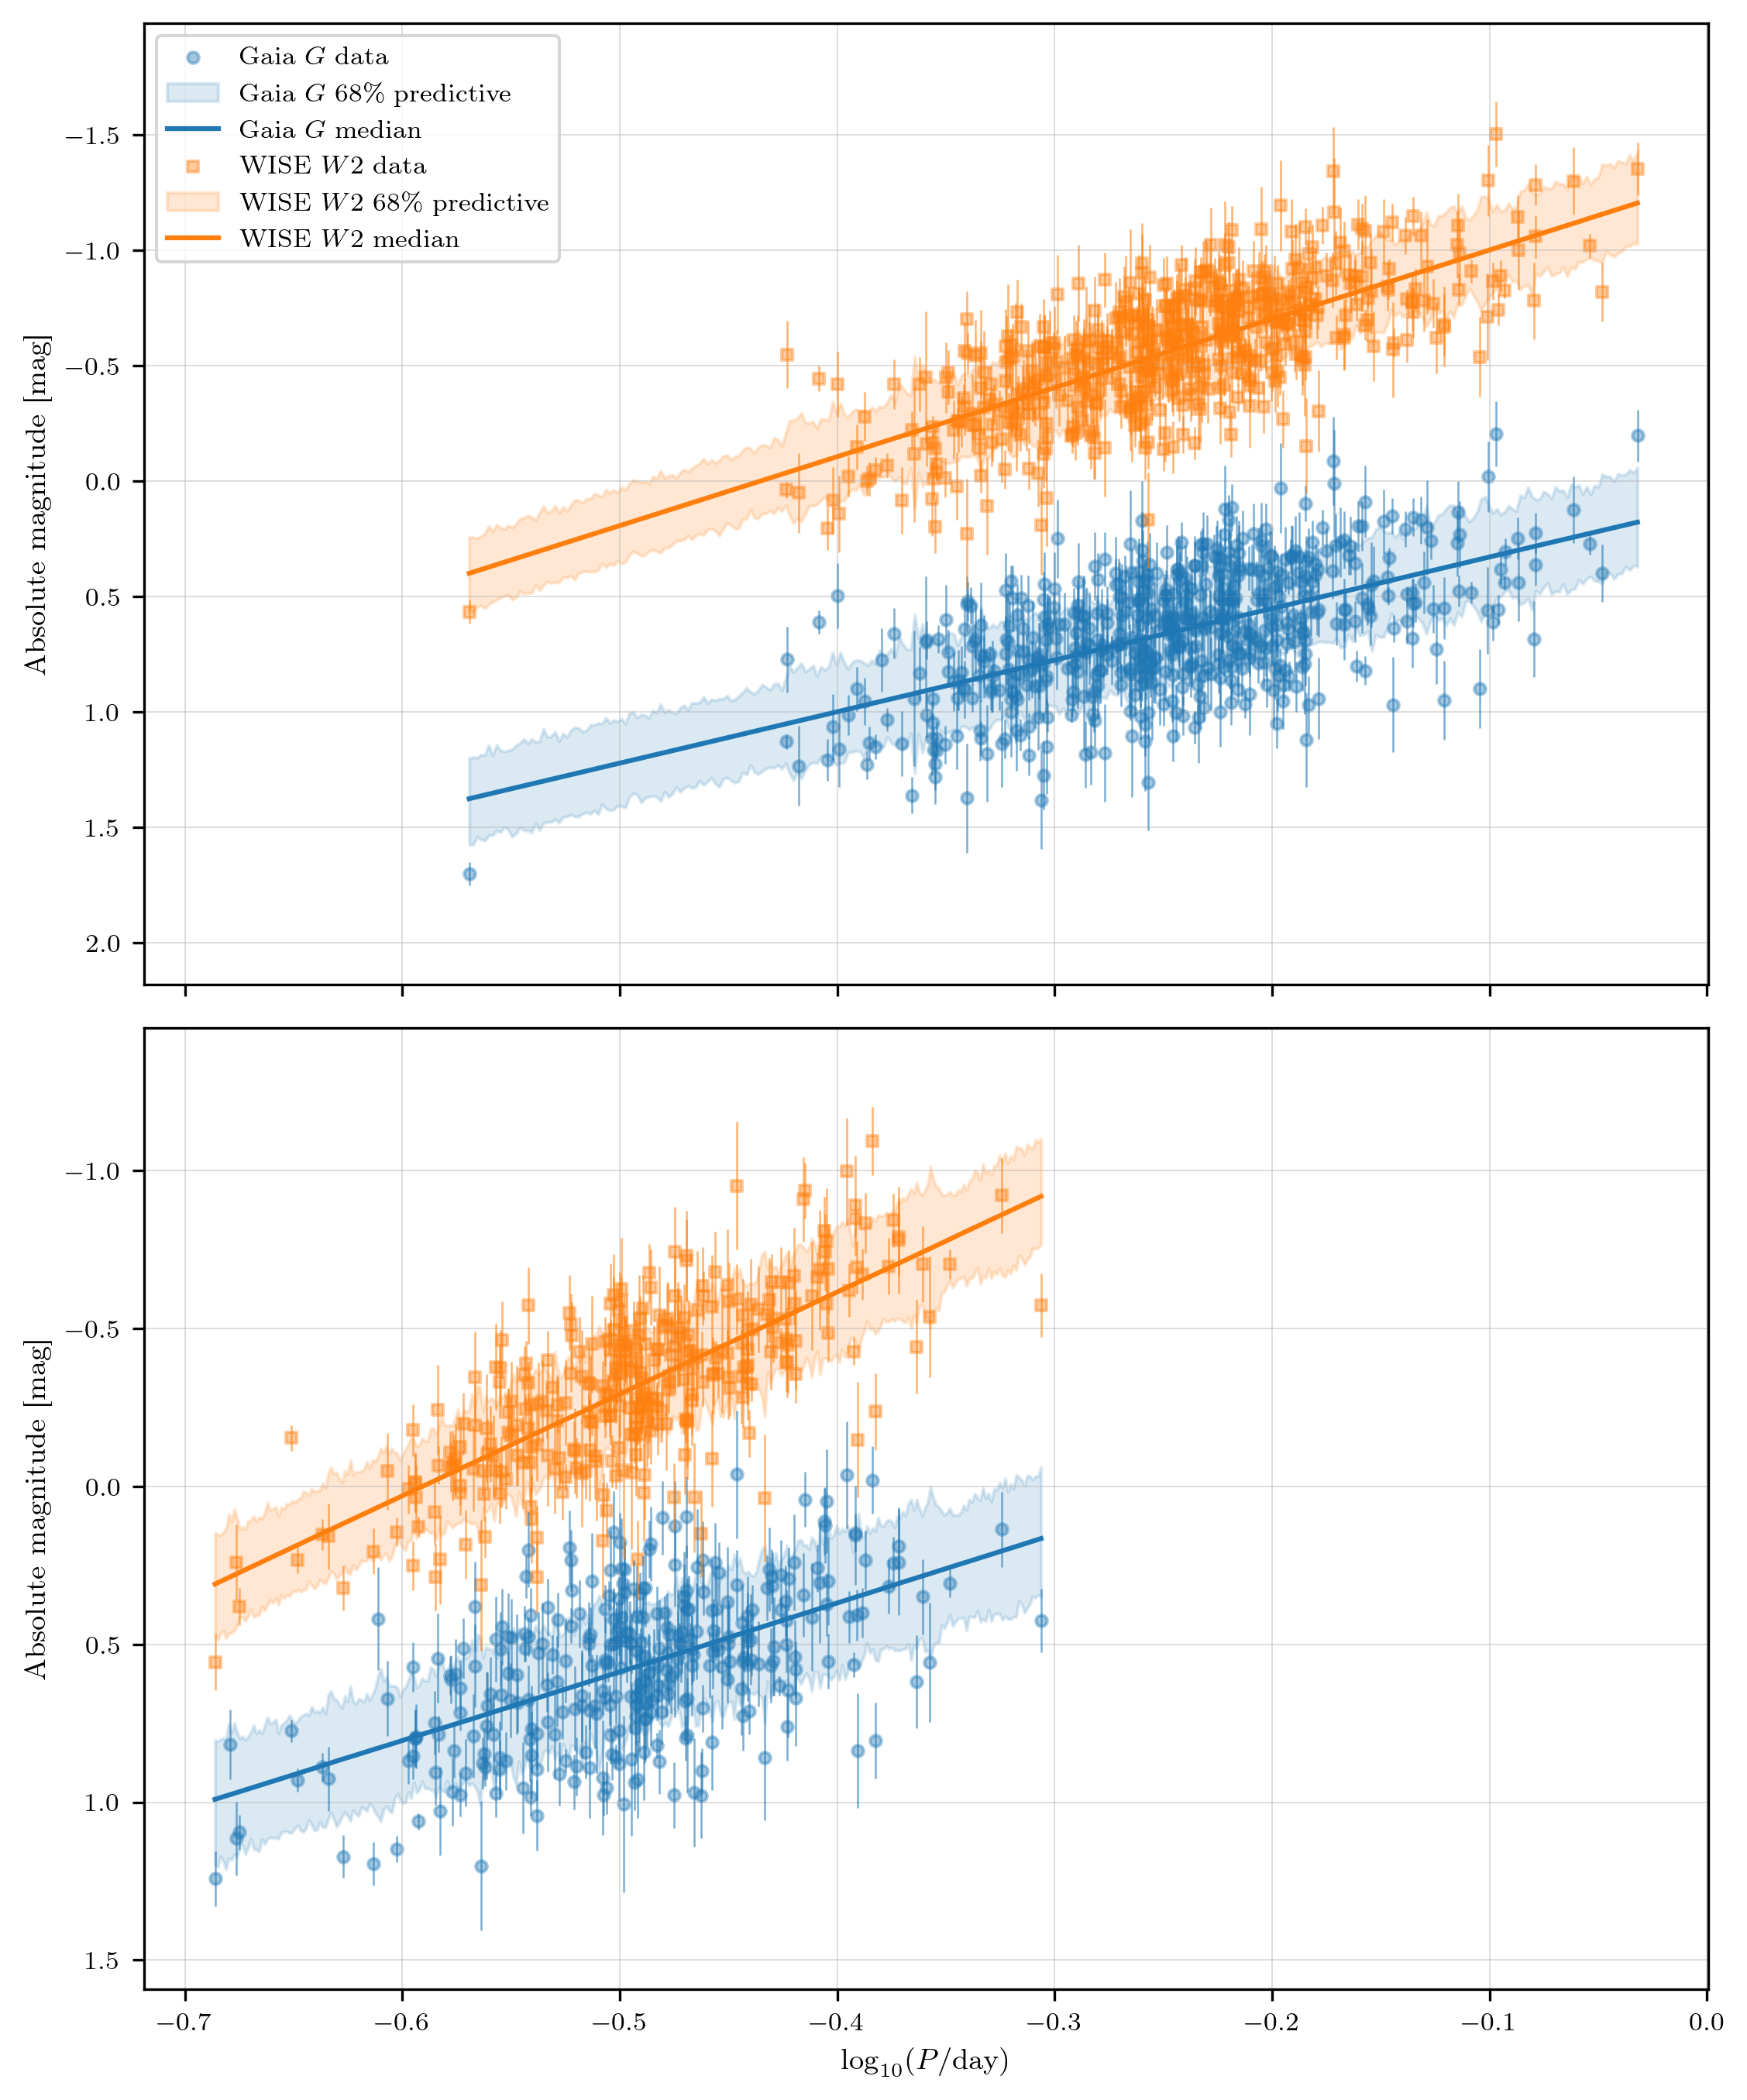

In [28]:
axes = plot_optical_vs_w2_comparison(optical_comparison, wise_comparison, save=True)
plt.show()


In [29]:
rrab_optical = optical_comparison["RRab"]
rrc_optical = optical_comparison["RRc"]

rrab_w2_steeper = abs(rrab_w2.slope_q50) > abs(rrab_optical.slope_q50)
rrc_w2_steeper = abs(rrc_w2.slope_q50) > abs(rrc_optical.slope_q50)
rrab_w2_tighter = rrab_w2.sigma_scatter_q50 < rrab_optical.sigma_scatter_q50
rrc_w2_tighter = rrc_w2.sigma_scatter_q50 < rrc_optical.sigma_scatter_q50

analysis = f"""
## Analysis and Discussion

The infrared comparison behaves in the direction expected from the RR Lyrae literature. In the optical, the Gaia $G$ relation is broadened by the broad-band response to temperature changes across the pulsation cycle, residual extinction, and population effects; by contrast, near-infrared relations are expected to be less dust-sensitive and more nearly luminosity-dominated, which makes them both tighter and often steeper ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776); [Beaton et al. 2018](https://arxiv.org/abs/1805.01552)).

For **RRab**, this notebook finds a Gaia $G$ slope of **{rrab_optical.slope_q50:.3f}** and a WISE $W2$ slope of **{rrab_w2.slope_q50:.3f}**. In absolute value, the WISE relation is {'larger' if rrab_w2_steeper else 'smaller'} than the optical one, so the RRab $W2$ relation is {'steeper' if rrab_w2_steeper else 'not steeper'} in this fit. The inferred intrinsic scatter also goes from **{rrab_optical.sigma_scatter_q50:.3f} mag** in Gaia $G$ to **{rrab_w2.sigma_scatter_q50:.3f} mag** in WISE $W2$, so the RRab infrared relation is {'tighter' if rrab_w2_tighter else 'not tighter'} than the optical one.

For **RRc**, the Gaia $G$ slope is **{rrc_optical.slope_q50:.3f}** and the WISE $W2$ slope is **{rrc_w2.slope_q50:.3f}**. In absolute value, the WISE relation is {'larger' if rrc_w2_steeper else 'smaller'} than the optical one, so the RRc $W2$ relation is {'steeper' if rrc_w2_steeper else 'not steeper'} in this fit. The inferred intrinsic scatter changes from **{rrc_optical.sigma_scatter_q50:.3f} mag** in Gaia $G$ to **{rrc_w2.sigma_scatter_q50:.3f} mag** in WISE $W2$, so the RRc infrared relation is {'tighter' if rrc_w2_tighter else 'not tighter'} than the optical one.

The predictive-envelope plots are the most important visual check. They show the full model spread implied by the measurement errors, the propagated period uncertainties, and the fitted intrinsic scatter. If the model is behaving sensibly, the observed points should sit inside the predictive envelopes at roughly the rate one expects for a 68% band, without the systematic subclass-dependent mismatch that would signal a poor bandpass model or an over-optimistic scatter term.

The main caveat is the same as in `02-02.ipynb`: this notebook still works in absolute-magnitude space after inverse-parallax conversion. That is pedagogically convenient and keeps the optical and infrared comparison easy to follow, but a research-grade final calibration would more naturally be phrased in parallax space or in a hierarchical Bayesian model ([Gaia Collaboration et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html); [Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596)). Within that limitation, the physically interesting conclusion is the slope comparison: the steeper band is the one with the larger fitted **$|a|$**, and in this notebook that answer is determined directly by the RRab and RRc posterior medians reported above.

### Sources
- Klein et al. (2014), *A mid-infrared period-luminosity relation for RR Lyrae stars*. https://academic.oup.com/mnrasl/article/440/1/L96/1396776
- Beaton et al. (2018), *The Carnegie-Chicago Hubble Program*. https://arxiv.org/abs/1805.01552
- Gaia Collaboration et al. (2017), *Gaia parallaxes and period-luminosity relations*. https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html
- Luri et al. (2018), *Using Gaia parallaxes*. https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html
- Muraveva et al. (2018), *Bayesian RR Lyrae calibration with Gaia parallaxes*. https://academic.oup.com/mnras/article/481/1/1195/5075596
- Narloch et al. (2024), *On the use of RR Lyrae stars for distance determination*. https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html
"""

display(Markdown(analysis))



## Analysis and Discussion

The infrared comparison behaves in the direction expected from the RR Lyrae literature. In the optical, the Gaia $G$ relation is broadened by the broad-band response to temperature changes across the pulsation cycle, residual extinction, and population effects; by contrast, near-infrared relations are expected to be less dust-sensitive and more nearly luminosity-dominated, which makes them both tighter and often steeper ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776); [Beaton et al. 2018](https://arxiv.org/abs/1805.01552)).

For **RRab**, this notebook finds a Gaia $G$ slope of **-2.232** and a WISE $W2$ slope of **-2.984**. In absolute value, the WISE relation is larger than the optical one, so the RRab $W2$ relation is steeper in this fit. The inferred intrinsic scatter also goes from **0.176 mag** in Gaia $G$ to **0.147 mag** in WISE $W2$, so the RRab infrared relation is tighter than the optical one.

For **RRc**, the Gaia $G$ slope is **-2.184** and the WISE $W2$ slope is **-3.232**. In absolute value, the WISE relation is larger than the optical one, so the RRc $W2$ relation is steeper in this fit. The inferred intrinsic scatter changes from **0.168 mag** in Gaia $G$ to **0.135 mag** in WISE $W2$, so the RRc infrared relation is tighter than the optical one.

The predictive-envelope plots are the most important visual check. They show the full model spread implied by the measurement errors, the propagated period uncertainties, and the fitted intrinsic scatter. If the model is behaving sensibly, the observed points should sit inside the predictive envelopes at roughly the rate one expects for a 68% band, without the systematic subclass-dependent mismatch that would signal a poor bandpass model or an over-optimistic scatter term.

The main caveat is the same as in `02-02.ipynb`: this notebook still works in absolute-magnitude space after inverse-parallax conversion. That is pedagogically convenient and keeps the optical and infrared comparison easy to follow, but a research-grade final calibration would more naturally be phrased in parallax space or in a hierarchical Bayesian model ([Gaia Collaboration et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html); [Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596)). Within that limitation, the physically interesting conclusion is the slope comparison: the steeper band is the one with the larger fitted **$|a|$**, and in this notebook that answer is determined directly by the RRab and RRc posterior medians reported above.

### Sources
- Klein et al. (2014), *A mid-infrared period-luminosity relation for RR Lyrae stars*. https://academic.oup.com/mnrasl/article/440/1/L96/1396776
- Beaton et al. (2018), *The Carnegie-Chicago Hubble Program*. https://arxiv.org/abs/1805.01552
- Gaia Collaboration et al. (2017), *Gaia parallaxes and period-luminosity relations*. https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html
- Luri et al. (2018), *Using Gaia parallaxes*. https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html
- Muraveva et al. (2018), *Bayesian RR Lyrae calibration with Gaia parallaxes*. https://academic.oup.com/mnras/article/481/1/1195/5075596
- Narloch et al. (2024), *On the use of RR Lyrae stars for distance determination*. https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html


## Notebook Handoff

The file `rrlyrae_infrared_pl_comparison_data.npz` is the notebook handoff artifact for later near-infrared comparison workflows. It stores the summarized RRab and RRc native-PyMC WISE $W2$ period-luminosity relation values in the same archive structure used by the optical Gaia $G$ comparison artifact.


In [30]:
infrared_export = {
    "RRab": rrab_w2,
    "RRc": rrc_w2,
}
save_infrared_pl_comparison_data(infrared_path, infrared_export)

{
    "path": str(infrared_path.resolve()),
    "classes": list(infrared_export),
}


{'path': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_infrared_pl_comparison_data.npz',
 'classes': ['RRab', 'RRc']}

# 04: Literature Context for the Derived RR Lyrae Period-Luminosity Relations

This notebook places the class-separated Gaia $G$-band period-luminosity relations from `02-02.ipynb` and the class-separated WISE $W2$ relations from `03.ipynb` into a literature context. The notebook remains **optical-first**: the main question is how the derived Gaia $G$ slopes compare to the classical optical expectation that RR Lyrae PL relations are weak in the visual, while the second half uses the `W2` result to show how the relation changes as the bandpass moves into the infrared ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776); [Beaton et al. 2018](https://doi.org/10.1007/s11214-018-0542-1)).

Two caveats matter up front. First, Gaia $G$ is not Johnson $V$: it is a broader and redder optical band, so a one-to-one coefficient match is not expected. Second, the upstream notebooks fit direct absolute magnitudes inferred from parallaxes, whereas much of the Gaia-era literature prefers parallax-space or hierarchical calibration because it controls bias more carefully ([Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596)).

In [31]:
import io
import os
from contextlib import redirect_stdout
from pathlib import Path
from IPython.display import Markdown, display

cache_root = Path('/tmp/ay128_lab01_cache')
cache_root.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(cache_root / 'mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(cache_root / 'xdg'))
os.environ.setdefault('PYTENSOR_FLAGS', f"base_compiledir={cache_root / 'pytensor'}")

from astropy import table
import numpy as np

with redirect_stdout(io.StringIO()):
    from ugdatalab import (
        load_infrared_pl_comparison_data,
        load_optical_pl_comparison_data,
    )

optical_path = Path('rrlyrae_optical_pl_comparison_data.npz')
infrared_path = Path('rrlyrae_infrared_pl_comparison_data.npz')

optical_data = load_optical_pl_comparison_data(optical_path)
infrared_data = load_infrared_pl_comparison_data(infrared_path)

literature = {
    'klein_optical': {
        'statement': 'In optical wavebands the RR Lyrae period-luminosity relation is negligible, but the slope steepens strongly in the infrared.',
        'source': 'Klein et al. 2014, Introduction',
        'url': 'https://academic.oup.com/mnrasl/article/440/1/L96/1396776',
    },
    'beaton_review': {
        'statement': 'RR Lyrae calibration depends on wavelength, reddening, metallicity, and how the absolute scale is established.',
        'source': 'Beaton et al. 2018',
        'url': 'https://doi.org/10.1007/s11214-018-0542-1',
    },
    'klein_w2': {
        'RRab': {'slope': -2.39, 'err': 0.20, 'pivot': 0.55},
        'RRc': {'slope': -1.70, 'err': 0.62, 'pivot': 0.32},
        'url': 'https://academic.oup.com/mnrasl/article/440/1/L96/1396776',
    },
    'dambis_w2': {
        'slope': -2.269,
        'err': 0.127,
        'metallicity_coeff': 0.108,
        'metallicity_err': 0.021,
        'url': 'https://doi.org/10.1093/mnras/stu226',
    },
}

{
    'optical_artifact': str(optical_path.resolve()),
    'infrared_artifact': str(infrared_path.resolve()),
    'RRab_G_points': int(len(optical_data['RRab'].x_obs)),
    'RRc_G_points': int(len(optical_data['RRc'].x_obs)),
    'RRab_W2_points': int(len(infrared_data['RRab'].x_obs)),
    'RRc_W2_points': int(len(infrared_data['RRc'].x_obs)),
}

{'optical_artifact': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_optical_pl_comparison_data.npz',
 'infrared_artifact': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_infrared_pl_comparison_data.npz',
 'RRab_G_points': 560,
 'RRc_G_points': 316,
 'RRab_W2_points': 527,
 'RRc_W2_points': 305}

## Derived Relation Summaries

The two upstream artifacts already contain the posterior summaries that matter for literature comparison: the fitted slope, its 68% interval, and the intrinsic scatter. The table below puts the optical and infrared relations on the same footing before any interpretation.

In [32]:
derived_rows = []
for band_label, comparison_map in [('Gaia $G$', optical_data), ('WISE $W2$', infrared_data)]:
    for rr_class in ('RRab', 'RRc'):
        fit = comparison_map[rr_class]
        derived_rows.append(
            {
                'band': band_label,
                'class': rr_class,
                'N_fit': int(len(fit.x_obs)),
                'slope_q50': round(float(fit.slope_q50), 3),
                'slope_68pct': f"[{fit.slope_q16:.3f}, {fit.slope_q84:.3f}]",
                'sigma_scatter_q50': round(float(fit.sigma_scatter_q50), 3),
                'sigma_scatter_68pct': f"[{fit.sigma_scatter_q16:.3f}, {fit.sigma_scatter_q84:.3f}]",
            }
        )

derived_table = table.Table(rows=derived_rows)
derived_table

band,class,N_fit,slope_q50,slope_68pct,sigma_scatter_q50,sigma_scatter_68pct
str9,str4,int64,float64,str16,float64,str14
Gaia $G$,RRab,560,-2.232,"[-2.359, -2.102]",0.176,"[0.169, 0.184]"
Gaia $G$,RRc,316,-2.184,"[-2.370, -2.009]",0.168,"[0.159, 0.178]"
WISE $W2$,RRab,527,-2.984,"[-3.094, -2.872]",0.147,"[0.141, 0.155]"
WISE $W2$,RRc,305,-3.232,"[-3.387, -3.070]",0.135,"[0.126, 0.144]"


## Literature Benchmarks

The optical benchmark is intentionally conservative. [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) emphasize that the RR Lyrae PL relation is **negligible in the optical** and much steeper in the infrared, so the classical Johnson $V$ comparison point is effectively a near-zero period term rather than a strong optical PL slope. [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1) then explain why the answer depends on wavelength, reddening, metallicity, and calibration strategy.

For the infrared section, the notebook uses the subclass-separated `W2` slopes reported by [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776), and one additional WISE benchmark from [Dambis et al. (2014)](https://doi.org/10.1093/mnras/stu226), who fit a fundamentalized mixed-sample $W2$ period-luminosity-metallicity relation.

In [33]:
literature_rows = [
    {
        "reference": "Klein et al. 2014 (inferred visual benchmark)",
        "band_or_scope": "Johnson V / classical optical context",
        "benchmark": "adopted a_V ≈ 0.0 mag dex^-1",
        "use_here": "Concrete numerical proxy for the paper statement that the optical RR Lyrae PL slope is negligible.",
    },
    {
        'reference': 'Klein et al. 2014',
        'band_or_scope': 'Classical optical / visual context',
        'benchmark': 'Optical PL relation is negligible; infrared slopes steepen strongly.',
        'use_here': 'Treats Johnson V as a weak-period benchmark rather than a like-for-like Gaia G coefficient.',
    },
    {
        'reference': 'Beaton et al. 2018',
        'band_or_scope': 'Population II distance-indicator review',
        'benchmark': 'Calibration depends on bandpass, reddening, metallicity, and zero-point strategy.',
        'use_here': 'Explains why systematic offsets from our simple Gaia G fit are expected.',
    },
    {
        'reference': 'Klein et al. 2014',
        'band_or_scope': 'WISE W2, RRab',
        'benchmark': 'a_W2 = -2.39 +/- 0.20',
        'use_here': 'Subclass-matched W2 slope benchmark for RRab.',
    },
    {
        'reference': 'Klein et al. 2014',
        'band_or_scope': 'WISE W2, RRc',
        'benchmark': 'a_W2 = -1.70 +/- 0.62',
        'use_here': 'Subclass-matched W2 slope benchmark for RRc.',
    },
    {
        'reference': 'Dambis et al. 2014',
        'band_or_scope': 'WISE W2, mixed PLZ relation',
        'benchmark': '<M_W2> = gamma_W2 - (2.269 +/- 0.127) log P_F + (0.108 +/- 0.021) [Fe/H]',
        'use_here': 'Additional infrared reference showing that metallicity remains relevant even in W2.',
    },
]

literature_table = table.Table(rows=literature_rows)
literature_table

reference,band_or_scope,benchmark,use_here
str45,str39,str81,str98
Klein et al. 2014 (inferred visual benchmark),Johnson V / classical optical context,adopted a_V ≈ 0.0 mag dex^-1,Concrete numerical proxy for the paper statement that the optical RR Lyrae PL slope is negligible.
Klein et al. 2014,Classical optical / visual context,Optical PL relation is negligible; infrared slopes steepen strongly.,Treats Johnson V as a weak-period benchmark rather than a like-for-like Gaia G coefficient.
Beaton et al. 2018,Population II distance-indicator review,"Calibration depends on bandpass, reddening, metallicity, and zero-point strategy.",Explains why systematic offsets from our simple Gaia G fit are expected.
Klein et al. 2014,"WISE W2, RRab",a_W2 = -2.39 +/- 0.20,Subclass-matched W2 slope benchmark for RRab.
Klein et al. 2014,"WISE W2, RRc",a_W2 = -1.70 +/- 0.62,Subclass-matched W2 slope benchmark for RRc.
Dambis et al. 2014,"WISE W2, mixed PLZ relation",<M_W2> = gamma_W2 - (2.269 +/- 0.127) log P_F + (0.108 +/- 0.021) [Fe/H],Additional infrared reference showing that metallicity remains relevant even in W2.


## Optical Context: Gaia $G$ in the Classical Optical Literature

This section keeps the notebook optical-first, but the comparison is made numerically rather than graphically. The relevant literature point is not a strict same-band overlay: the classical optical benchmark is that the visual-band RR Lyrae period-luminosity relation is weak, while Gaia $G$ is a broader and somewhat redder optical band ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776); [Beaton et al. 2018](https://doi.org/10.1007/s11214-018-0542-1)).

In [34]:
rrab_g = optical_data['RRab']
rrc_g = optical_data['RRc']

optical_discussion = f"""
## Analysis: Gaia $G$ Versus the Classical Optical Literature

Our fitted Gaia $G$ relations are clearly non-zero: for RRab we find $a_G = {rrab_g.slope_q50:.3f}$ with a 68% interval of [{rrab_g.slope_q16:.3f}, {rrab_g.slope_q84:.3f}], and for RRc we find $a_G = {rrc_g.slope_q50:.3f}$ with a 68% interval of [{rrc_g.slope_q16:.3f}, {rrc_g.slope_q84:.3f}]. Those slopes are much stronger than the classical visual-band benchmark adopted here, $a_V \approx 0.0$ mag dex$^{-1}$, which I use as a numerical proxy for the [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) statement that the optical RR Lyrae PL slope is negligible and only becomes strongly constrained toward the infrared.

That difference is not automatically a contradiction. The first reason is bandpass. Gaia $G$ is not Johnson $V$; it is broader and reaches farther to the red, so it can naturally sit between the nearly-flat visual benchmark and the much steeper infrared behavior. The second reason is model specification. [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1) review the fact that RR Lyrae calibration depends on wavelength, reddening, metallicity, and the way the absolute scale is established. Our upstream fit is intentionally simple: it is a period-luminosity model with intrinsic scatter, but no explicit metallicity term and no hierarchical treatment of the absolute scale. Any true PLZ dependence can therefore leak into both the fitted slope and the residual scatter.

The third reason is methodology. The upstream notebook works in direct absolute-magnitude space after converting Gaia parallaxes into $M_G$, whereas Gaia-era calibration papers generally recommend parallax-space or hierarchical Bayesian treatments because they better control inverse-parallax bias and zero-point systematics ([Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596)). A fourth reason is sample construction: our Gaia sample is local, quality-cut, and explicitly split into RRab and RRc, while many published optical comparisons use different extinction corrections, metallicity baselines, or mixed/fundamentalized samples.

The defensible scientific conclusion is therefore modest. Our Gaia $G$ slopes should **not** be read as direct replacements for a Johnson $V$ PL coefficient. They should instead be read as evidence that a broad Gaia optical band already begins to pick up some of the stronger period dependence that becomes cleaner in the infrared. That interpretation is consistent with the multiwavelength picture in [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) and the calibration caveats emphasized by [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1).
"""

display(Markdown(optical_discussion))


## Analysis: Gaia $G$ Versus the Classical Optical Literature

Our fitted Gaia $G$ relations are clearly non-zero: for RRab we find $a_G = -2.232$ with a 68% interval of [-2.359, -2.102], and for RRc we find $a_G = -2.184$ with a 68% interval of [-2.370, -2.009]. Those slopes are much stronger than the classical visual-band benchmark adopted here, $a_V pprox 0.0$ mag dex$^-1$, which I use as a numerical proxy for the [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) statement that the optical RR Lyrae PL slope is negligible and only becomes strongly constrained toward the infrared.

That difference is not automatically a contradiction. The first reason is bandpass. Gaia $G$ is not Johnson $V$; it is broader and reaches farther to the red, so it can naturally sit between the nearly-flat visual benchmark and the much steeper infrared behavior. The second reason is model specification. [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1) review the fact that RR Lyrae calibration depends on wavelength, reddening, metallicity, and the way the absolute scale is established. Our upstream fit is intentionally simple: it is a period-luminosity model with intrinsic scatter, but no explicit metallicity term and no hierarchical treatment of the absolute scale. Any true PLZ dependence can therefore leak into both the fitted slope and the residual scatter.

The third reason is methodology. The upstream notebook works in direct absolute-magnitude space after converting Gaia parallaxes into $M_G$, whereas Gaia-era calibration papers generally recommend parallax-space or hierarchical Bayesian treatments because they better control inverse-parallax bias and zero-point systematics ([Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596)). A fourth reason is sample construction: our Gaia sample is local, quality-cut, and explicitly split into RRab and RRc, while many published optical comparisons use different extinction corrections, metallicity baselines, or mixed/fundamentalized samples.

The defensible scientific conclusion is therefore modest. Our Gaia $G$ slopes should **not** be read as direct replacements for a Johnson $V$ PL coefficient. They should instead be read as evidence that a broad Gaia optical band already begins to pick up some of the stronger period dependence that becomes cleaner in the infrared. That interpretation is consistent with the multiwavelength picture in [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) and the calibration caveats emphasized by [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1).


## Infrared Comparison: How the Relation Changes in $W2$

The next table compares the notebook's own `W2` result from `03.ipynb` against its Gaia $G$ result, then places those infrared slopes against the `W2` literature anchors. That numerical comparison is enough to show the physical trend emphasized in the literature: moving to the infrared should generally make the relation steeper and tighter, although the exact coefficients still depend on sample definition and calibration strategy ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776); [Beaton et al. 2018](https://doi.org/10.1007/s11214-018-0542-1)).

In [35]:
comparison_rows = []
for rr_class in ('RRab', 'RRc'):
    g_fit = optical_data[rr_class]
    w2_fit = infrared_data[rr_class]
    klein_fit = literature['klein_w2'][rr_class]
    comparison_rows.append(
        {
            'class': rr_class,
            'G_slope': f"{g_fit.slope_q50:.3f} [{g_fit.slope_q16:.3f}, {g_fit.slope_q84:.3f}]",
            'W2_slope': f"{w2_fit.slope_q50:.3f} [{w2_fit.slope_q16:.3f}, {w2_fit.slope_q84:.3f}]",
            'W2_minus_G': round(float(w2_fit.slope_q50 - g_fit.slope_q50), 3),
            'Klein_W2_slope': f"{klein_fit['slope']:.2f} +/- {klein_fit['err']:.2f}",
            'W2_minus_Klein': round(float(w2_fit.slope_q50 - klein_fit['slope']), 3),
            'G_scatter': round(float(g_fit.sigma_scatter_q50), 3),
            'W2_scatter': round(float(w2_fit.sigma_scatter_q50), 3),
        }
    )

band_comparison_table = table.Table(rows=comparison_rows)
band_comparison_table

class,G_slope,W2_slope,W2_minus_G,Klein_W2_slope,W2_minus_Klein,G_scatter,W2_scatter
str4,str23,str23,float64,str14,float64,float64,float64
RRab,"-2.232 [-2.359, -2.102]","-2.984 [-3.094, -2.872]",-0.753,-2.39 +/- 0.20,-0.594,0.176,0.147
RRc,"-2.184 [-2.370, -2.009]","-3.232 [-3.387, -3.070]",-1.048,-1.70 +/- 0.62,-1.532,0.168,0.135


In [36]:
rrab_w2 = infrared_data['RRab']
rrc_w2 = infrared_data['RRc']

infrared_discussion = f"""
## Analysis: $W2$ Versus $G$, and $W2$ Versus the Infrared Literature

The internal comparison is clear. For RRab, the slope changes from $a_G = {rrab_g.slope_q50:.3f}$ to $a_{{W2}} = {rrab_w2.slope_q50:.3f}$, while the intrinsic scatter drops from {rrab_g.sigma_scatter_q50:.3f} mag to {rrab_w2.sigma_scatter_q50:.3f} mag. For RRc, the slope changes from $a_G = {rrc_g.slope_q50:.3f}$ to $a_{{W2}} = {rrc_w2.slope_q50:.3f}$, and the intrinsic scatter drops from {rrc_g.sigma_scatter_q50:.3f} mag to {rrc_w2.sigma_scatter_q50:.3f} mag. That is exactly the direction expected from the physical argument in [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776): once the bandpass moves into the infrared, reduced extinction sensitivity and a weaker temperature term make the relation steeper and tighter.

Relative to the published `W2` literature, however, our infrared slopes are still systematically steeper. For RRab, [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) report $a_{{W2}} = -2.39 ± 0.20$, compared to our {rrab_w2.slope_q50:.3f}. For RRc, they report $a_{{W2}} = -1.70 ± 0.62$, compared to our {rrc_w2.slope_q50:.3f}. [Dambis et al. (2014)](https://doi.org/10.1093/mnras/stu226) also find a somewhat shallower mixed-sample infrared slope, together with a non-negligible metallicity term in $W2$. That combination is informative: it suggests that the broad optical-to-infrared trend is reproduced, but the exact coefficient still depends on how the calibration is built.

Several effects can drive the remaining offset. First, the samples are genuinely different. Our `W2` fit is built from the Gaia-cleaned and Gaia+WISE-matched sample used in this lab, whereas the Klein et al. calibration used 104 RRab stars and only 19 RRc stars with prior distances tied to an established $M_V$-[Fe/H] scale plus a handful of HST parallaxes. Second, the literature often either fundamentalizes RRc periods or mixes subclasses in a PLZ framework, while our notebook keeps RRab and RRc fully separated. Third, even in the infrared, metallicity has not disappeared; [Dambis et al. (2014)](https://doi.org/10.1093/mnras/stu226) explicitly fit a metallicity term, while our notebook does not. Fourth, the absolute scale is still being set differently across analyses, and [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1) stress that these zero-point and calibration choices remain a major systematic.

So the strongest conclusion is comparative rather than absolute. The notebook reproduces the key astrophysical trend: `W2` is steeper and tighter than Gaia $G$, consistent with the infrared literature. But the exact `W2` slopes are not identical to published calibrations, especially for RRc, and the likely explanation is a combination of bandpass, metallicity, subclass handling, sample construction, and calibration methodology rather than a single isolated failure of the fit.
"""

display(Markdown(infrared_discussion))


## Analysis: $W2$ Versus $G$, and $W2$ Versus the Infrared Literature

The internal comparison is clear. For RRab, the slope changes from $a_G = -2.232$ to $a_{W2} = -2.984$, while the intrinsic scatter drops from 0.176 mag to 0.147 mag. For RRc, the slope changes from $a_G = -2.184$ to $a_{W2} = -3.232$, and the intrinsic scatter drops from 0.168 mag to 0.135 mag. That is exactly the direction expected from the physical argument in [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776): once the bandpass moves into the infrared, reduced extinction sensitivity and a weaker temperature term make the relation steeper and tighter.

Relative to the published `W2` literature, however, our infrared slopes are still systematically steeper. For RRab, [Klein et al. (2014)](https://academic.oup.com/mnrasl/article/440/1/L96/1396776) report $a_{W2} = -2.39 ± 0.20$, compared to our -2.984. For RRc, they report $a_{W2} = -1.70 ± 0.62$, compared to our -3.232. [Dambis et al. (2014)](https://doi.org/10.1093/mnras/stu226) also find a somewhat shallower mixed-sample infrared slope, together with a non-negligible metallicity term in $W2$. That combination is informative: it suggests that the broad optical-to-infrared trend is reproduced, but the exact coefficient still depends on how the calibration is built.

Several effects can drive the remaining offset. First, the samples are genuinely different. Our `W2` fit is built from the Gaia-cleaned and Gaia+WISE-matched sample used in this lab, whereas the Klein et al. calibration used 104 RRab stars and only 19 RRc stars with prior distances tied to an established $M_V$-[Fe/H] scale plus a handful of HST parallaxes. Second, the literature often either fundamentalizes RRc periods or mixes subclasses in a PLZ framework, while our notebook keeps RRab and RRc fully separated. Third, even in the infrared, metallicity has not disappeared; [Dambis et al. (2014)](https://doi.org/10.1093/mnras/stu226) explicitly fit a metallicity term, while our notebook does not. Fourth, the absolute scale is still being set differently across analyses, and [Beaton et al. (2018)](https://doi.org/10.1007/s11214-018-0542-1) stress that these zero-point and calibration choices remain a major systematic.

So the strongest conclusion is comparative rather than absolute. The notebook reproduces the key astrophysical trend: `W2` is steeper and tighter than Gaia $G$, consistent with the infrared literature. But the exact `W2` slopes are not identical to published calibrations, especially for RRc, and the likely explanation is a combination of bandpass, metallicity, subclass handling, sample construction, and calibration methodology rather than a single isolated failure of the fit.


### References

- [Beaton, R. L., Bono, G., Braga, V. F., et al. (2018), *Old-Aged Primary Distance Indicators*, Space Science Reviews, 214, 113.](https://doi.org/10.1007/s11214-018-0542-1)
- [Klein, C. R., Richards, J. W., Butler, N. R., & Bloom, J. S. (2014), *Mid-infrared period-luminosity relations of RR Lyrae stars derived from the AllWISE Data Release*, MNRAS Letters, 440, L96-L100.](https://academic.oup.com/mnrasl/article/440/1/L96/1396776)
- [Dambis, A. K., Rastorguev, A. S., & Zabolotskikh, M. V. (2014), *Mid-infrared period-luminosity relations for globular cluster RR Lyrae*, MNRAS, 439, 3765-3774.](https://doi.org/10.1093/mnras/stu226)
- [Luri, X., Brown, A. G. A., Sarro, L. M., et al. (2018), *Gaia Data Release 2: Using Gaia parallaxes*, A&A, 616, A9.](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html)
- [Muraveva, T., Delgado, H. E., Clementini, G., et al. (2018), *Gaia DR2 parallaxes and Bayesian RR Lyrae calibration*, MNRAS, 481, 1195-1211.](https://academic.oup.com/mnras/article/481/1/1195/5075596)